# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [ ]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import kagglehub
import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [ ]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

100%|██████████| 112M/112M [00:00<00:00, 150MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4


In [ ]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

100%|██████████| 6.49M/6.49M [00:00<00:00, 161MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/averkij/lfw-attributes/versions/1


In [ ]:
DATASET_PATH = os.path.join(images_path, "lfw-deepfunneled", "lfw-deepfunneled") + "/"
ATTRIBUTES_PATH = os.path.join(attrs_path, "lfw_attributes.txt")

In [ ]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [ ]:
for root, dirs, files in os.walk(images_path):
    print(root)
    if files:
        break

/root/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4


In [ ]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

Train: (11171, 45, 45, 3),  Val: (1972, 45, 45, 3)


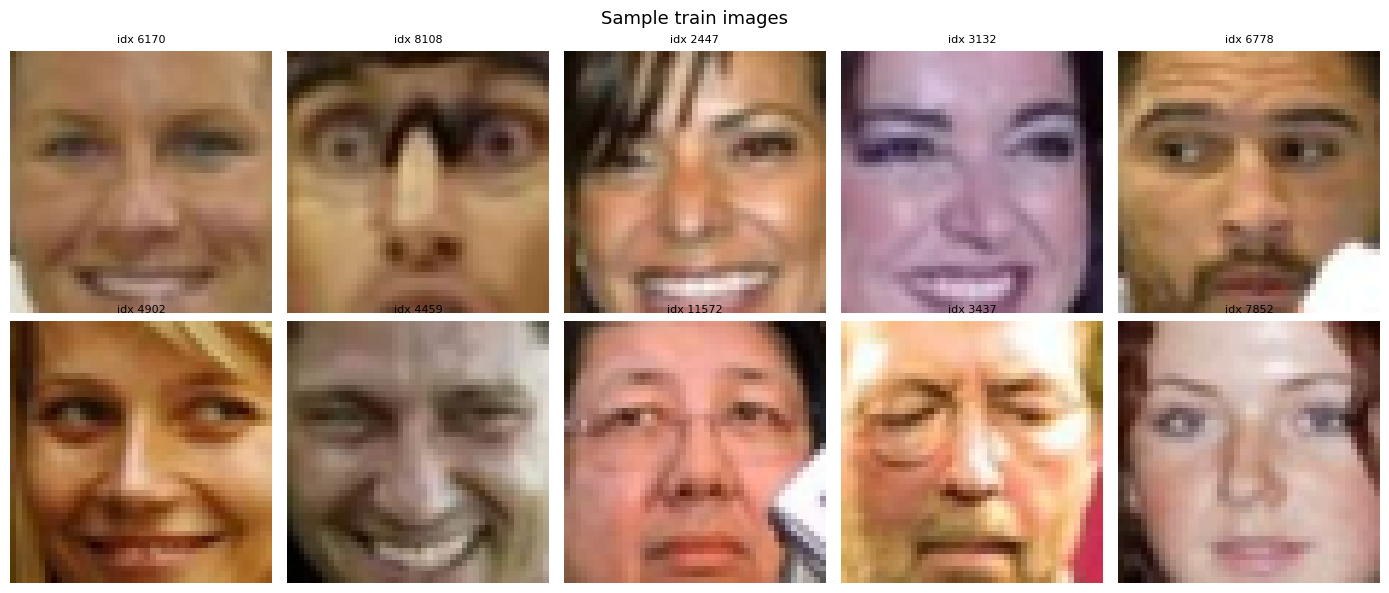

In [ ]:
np.random.seed(42)
idx = np.random.permutation(len(images))
split = int(0.85 * len(images))

train_idx, val_idx = idx[:split], idx[split:]

X_train = images[train_idx]
X_val   = images[val_idx]

attrs_train = attrs.iloc[train_idx].reset_index(drop=True)
attrs_val   = attrs.iloc[val_idx].reset_index(drop=True)

print(f"Train: {X_train.shape},  Val: {X_val.shape}")

os.makedirs("output", exist_ok=True)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(f"idx {train_idx[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Sample train images", fontsize=13)
plt.tight_layout()
plt.savefig("output/sample_images.png", dpi=100)
plt.show()

In [ ]:
def to_tensor(imgs: np.ndarray) -> torch.FloatTensor:
    """uint8 (N, H, W, C) → float32 (N, C, H, W) in [0, 1]"""
    return torch.tensor(imgs, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0

X_train_t = to_tensor(X_train)   # (N_train, 3, 45, 45)
X_val_t   = to_tensor(X_val)     # (N_val,   3, 45, 45)

print(f"Train tensor: {X_train_t.shape}, dtype={X_train_t.dtype}")
print(f"Val   tensor: {X_val_t.shape},   min={X_val_t.min():.2f}, max={X_val_t.max():.2f}")

BATCH_SIZE = 64

train_dataset = data_utils.TensorDataset(X_train_t)
val_dataset   = data_utils.TensorDataset(X_val_t)

train_loader = data_utils.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = data_utils.DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train batches: {len(train_loader)},  Val batches: {len(val_loader)}")

Train tensor: torch.Size([11171, 3, 45, 45]), dtype=torch.float32
Val   tensor: torch.Size([1972, 3, 45, 45]),   min=0.00, max=1.00
Train batches: 174,  Val batches: 31


## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.


In [ ]:
IMG_SIZE   = 45
IMG_SHAPE  = (3, IMG_SIZE, IMG_SIZE)
INPUT_DIM  = 3 * IMG_SIZE * IMG_SIZE

dim_code = 256

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, dim_code):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 512),       nn.ReLU(),
            nn.Linear(512, dim_code),   nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x.reshape(x.size(0), -1))


class Decoder(nn.Module):
    def __init__(self, dim_code, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_code, 512),   nn.ReLU(),
            nn.Linear(512, 1024),       nn.ReLU(),
            nn.Linear(1024, input_dim), nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z).view(-1, *IMG_SHAPE)


class Autoencoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, dim_code=dim_code):
        super().__init__()
        self.encoder = Encoder(input_dim, dim_code)
        self.decoder = Decoder(dim_code, input_dim)

    def forward(self, x):
        return self.decoder(self.encoder(x))


model = Autoencoder()
print(model)
print(f"\nПараметров всего: {sum(p.numel() for p in model.parameters()):,}")

Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=6075, out_features=1024, bias=True)
      (1): ReLU()
      (2): Linear(in_features=1024, out_features=512, bias=True)
      (3): ReLU()
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): ReLU()
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=1024, bias=True)
      (3): ReLU()
      (4): Linear(in_features=1024, out_features=6075, bias=True)
      (5): Sigmoid()
    )
  )
)

Параметров всего: 13,761,723


In [ ]:
criterion = nn.MSELoss()

autoencoder = Autoencoder().to(device)

optimizer   = optim.Adam(autoencoder.parameters(), lr=1e-3)

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

Epoch [ 1/25]  train=0.0244  val=0.0178


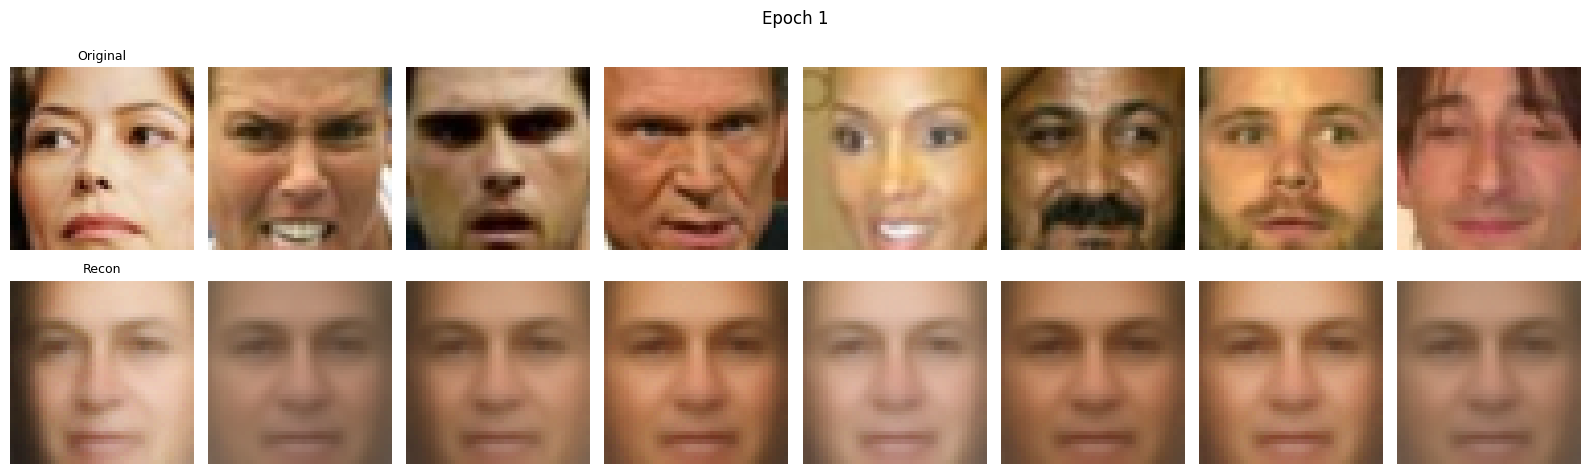

Epoch [ 2/25]  train=0.0146  val=0.0133
Epoch [ 3/25]  train=0.0125  val=0.0119
Epoch [ 4/25]  train=0.0118  val=0.0117
Epoch [ 5/25]  train=0.0108  val=0.0103


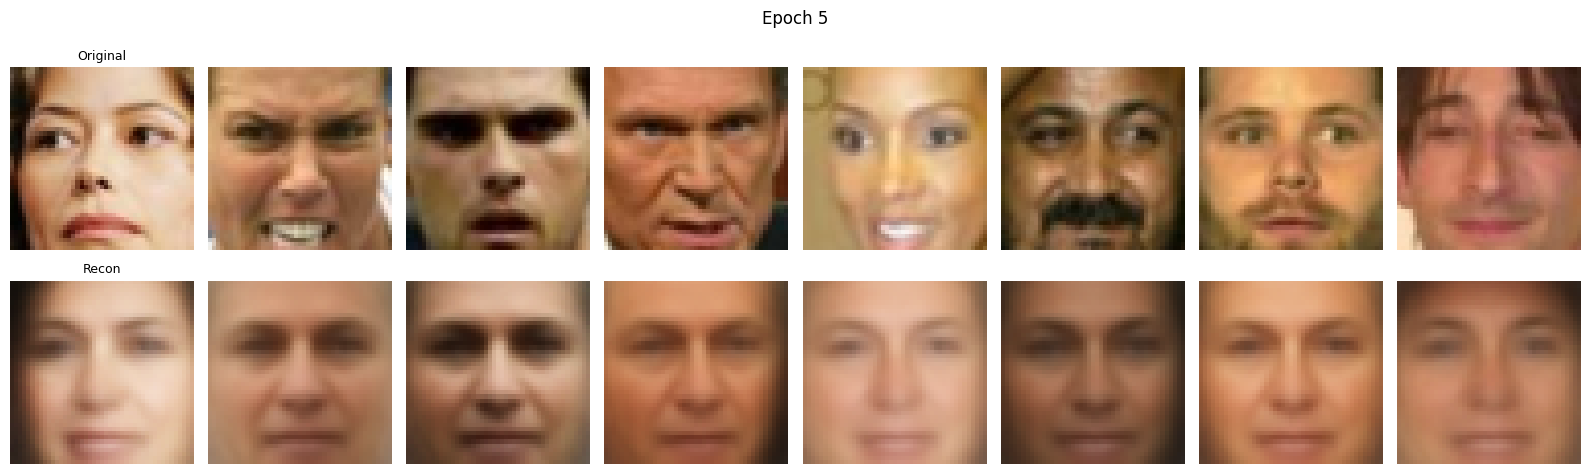

Epoch [ 6/25]  train=0.0103  val=0.0102
Epoch [ 7/25]  train=0.0101  val=0.0098
Epoch [ 8/25]  train=0.0097  val=0.0095
Epoch [ 9/25]  train=0.0092  val=0.0089
Epoch [10/25]  train=0.0088  val=0.0088


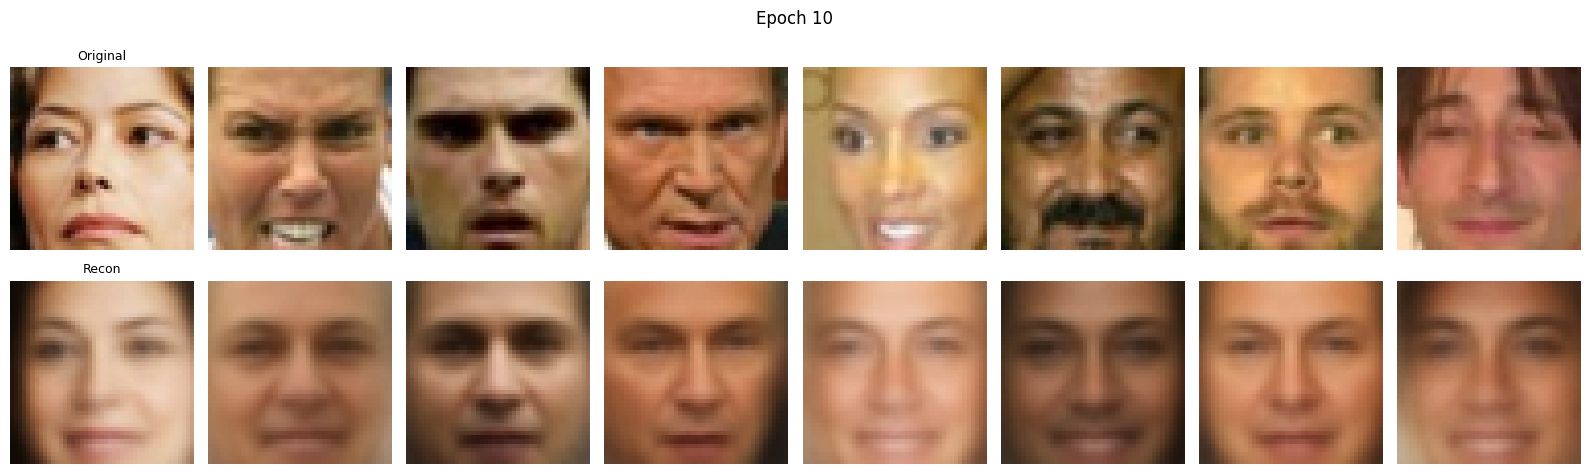

Epoch [11/25]  train=0.0087  val=0.0084
Epoch [12/25]  train=0.0082  val=0.0080
Epoch [13/25]  train=0.0079  val=0.0079
Epoch [14/25]  train=0.0077  val=0.0075
Epoch [15/25]  train=0.0074  val=0.0072


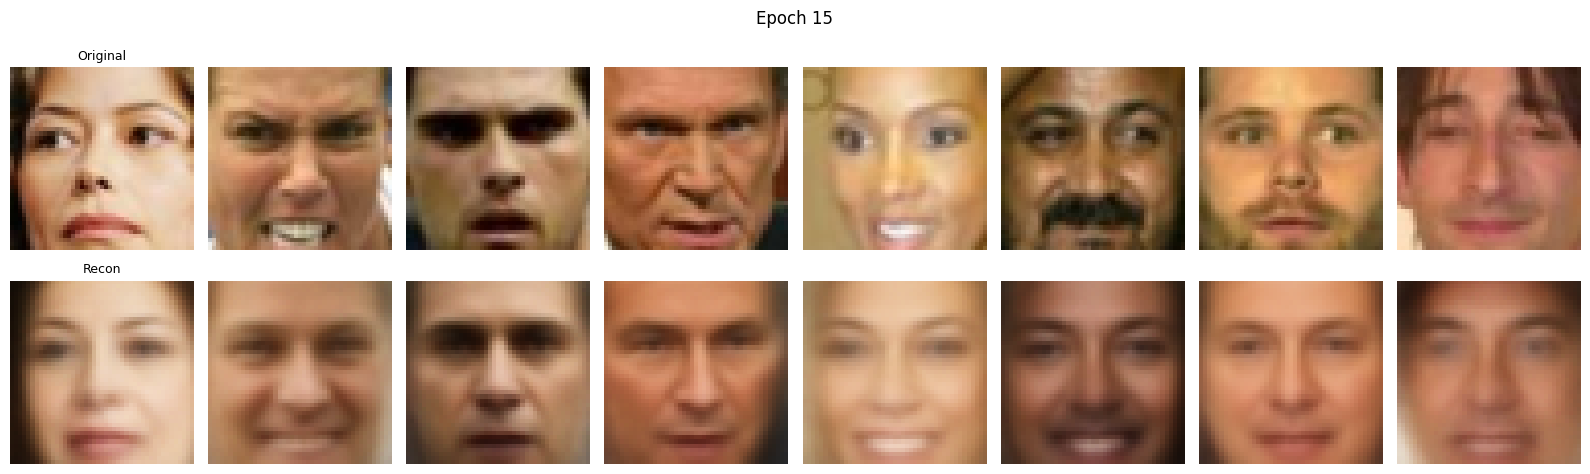

Epoch [16/25]  train=0.0072  val=0.0072
Epoch [17/25]  train=0.0071  val=0.0072
Epoch [18/25]  train=0.0070  val=0.0070
Epoch [19/25]  train=0.0070  val=0.0069
Epoch [20/25]  train=0.0068  val=0.0067


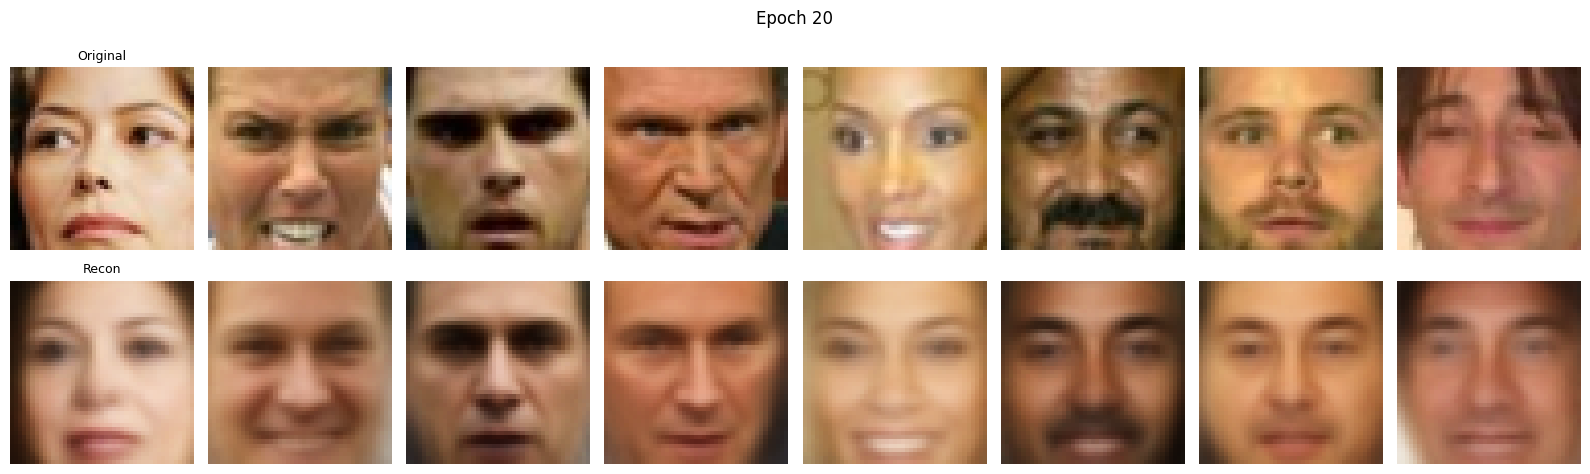

Epoch [21/25]  train=0.0066  val=0.0068
Epoch [22/25]  train=0.0065  val=0.0072
Epoch [23/25]  train=0.0064  val=0.0065
Epoch [24/25]  train=0.0064  val=0.0065
Epoch [25/25]  train=0.0063  val=0.0064


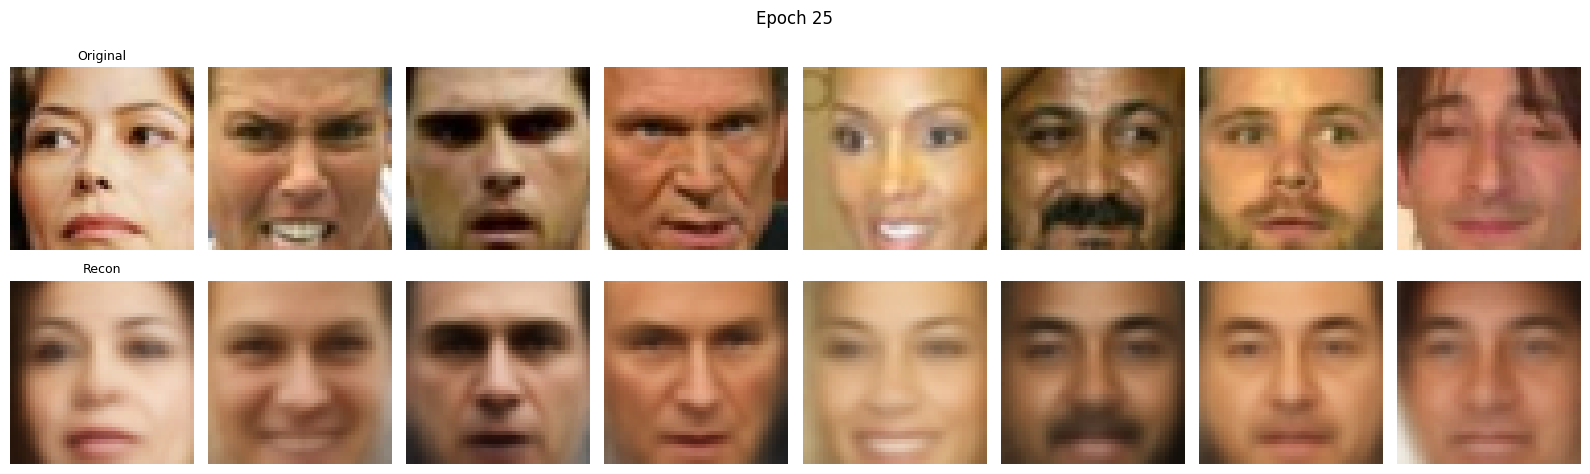

In [ ]:
EPOCHS = 25
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = autoencoder.to(device)

train_losses, val_losses = [], []

VIZ_N = 8
viz_imgs = X_val_t[:VIZ_N].to(device)

os.makedirs("output", exist_ok=True)

for epoch in range(1, EPOCHS + 1):

    autoencoder.train()
    running_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon = autoencoder(batch)
        loss  = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    autoencoder.eval()
    with torch.no_grad():
        val_loss = sum(criterion(autoencoder(b.to(device)), b.to(device)).item()
                       for (b,) in val_loader) / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch:>2}/{EPOCHS}]  train={train_loss:.4f}  val={val_loss:.4f}")

    if epoch % 5 == 0 or epoch == 1:
        with torch.no_grad():
            recons = autoencoder(viz_imgs).cpu()

        fig, axes = plt.subplots(2, VIZ_N, figsize=(VIZ_N * 2, 5))
        for i in range(VIZ_N):
            # Оригинал
            axes[0, i].imshow(viz_imgs[i].cpu().permute(1, 2, 0).clamp(0, 1))
            axes[0, i].axis('off')
            if i == 0: axes[0, i].set_title("Original", fontsize=9)
            # Реконструкция
            axes[1, i].imshow(recons[i].permute(1, 2, 0).clamp(0, 1))
            axes[1, i].axis('off')
            if i == 0: axes[1, i].set_title("Recon", fontsize=9)
        plt.suptitle(f"Epoch {epoch}", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"output/recon_epoch_{epoch:02d}.png", dpi=100)
        plt.show()

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

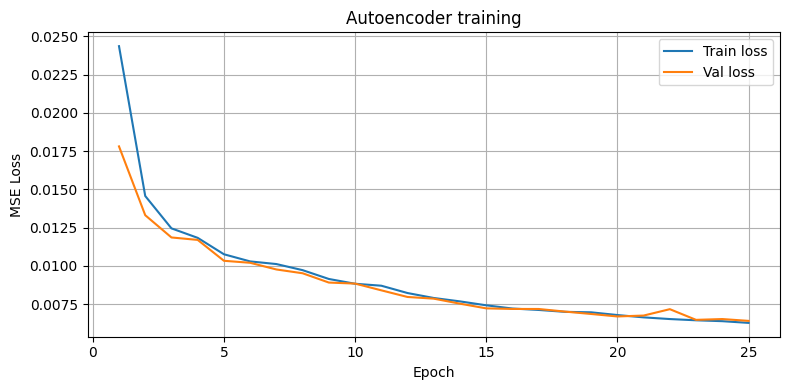

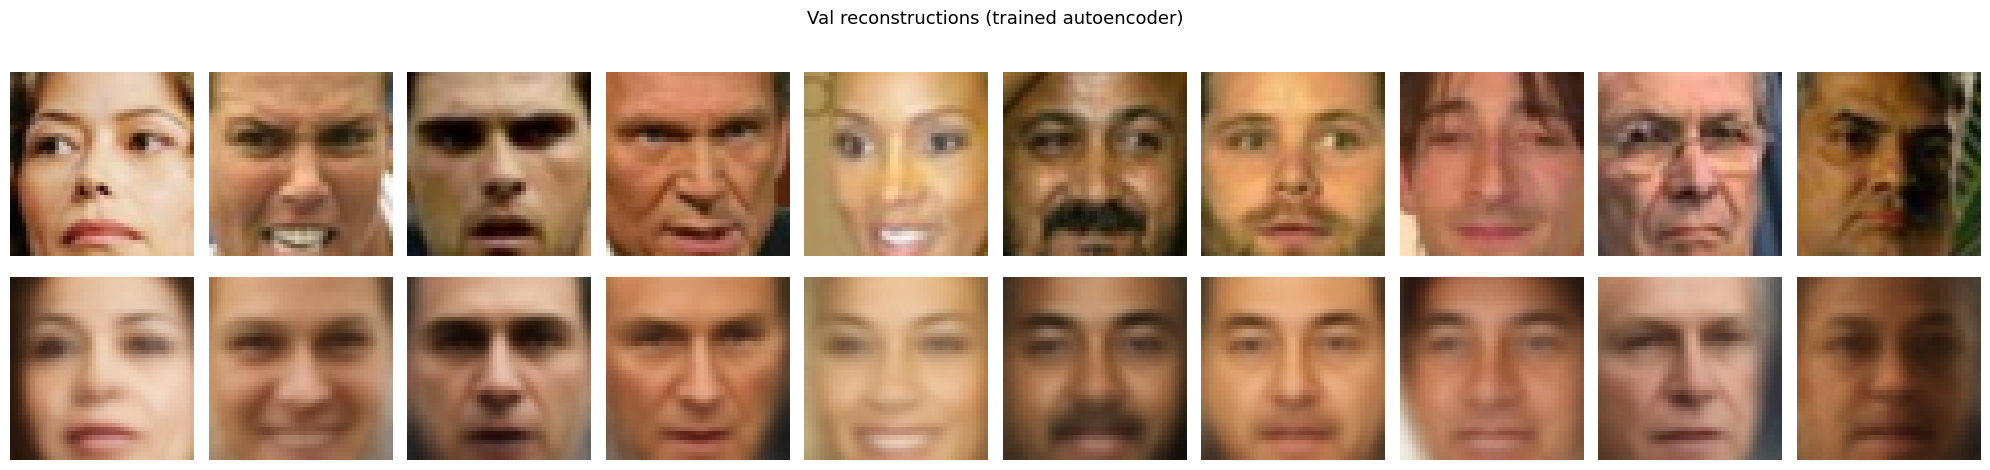

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train loss")
plt.plot(range(1, EPOCHS + 1), val_losses,   label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Autoencoder training"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig("output/loss_curve.png", dpi=100)
plt.show()

X_VIZ = 10
autoencoder.eval()
with torch.no_grad():
    originals = X_val_t[:X_VIZ].to(device)
    recons    = autoencoder(originals).cpu()

fig, axes = plt.subplots(2, X_VIZ, figsize=(X_VIZ * 2, 5))
for i in range(X_VIZ):
    axes[0, i].imshow(originals[i].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[0, i].axis('off')
    axes[1, i].imshow(recons[i].permute(1, 2, 0).clamp(0, 1))
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Reconstructed", fontsize=11)
plt.suptitle("Val reconstructions (trained autoencoder)", fontsize=13)
plt.tight_layout()
plt.savefig("output/final_reconstructions.png", dpi=100)
plt.show()

Что вы можете сказать про результат?

Достаточно быстрая сходимость (лосс снизился в 4 раза), не заметно переобучения, плато началось с 20 эпохи.
По поводу самих лиц: структура сохранена: контуры лица и положение глаз и носа совпадает, если есть зубы - они есть и в реконструкции, освещение похоже, есть размытие для усреднения пикселей.

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

Латентные векторы — mean: 0.1588, std: 0.4197
min: 0.0000, max: 4.8931


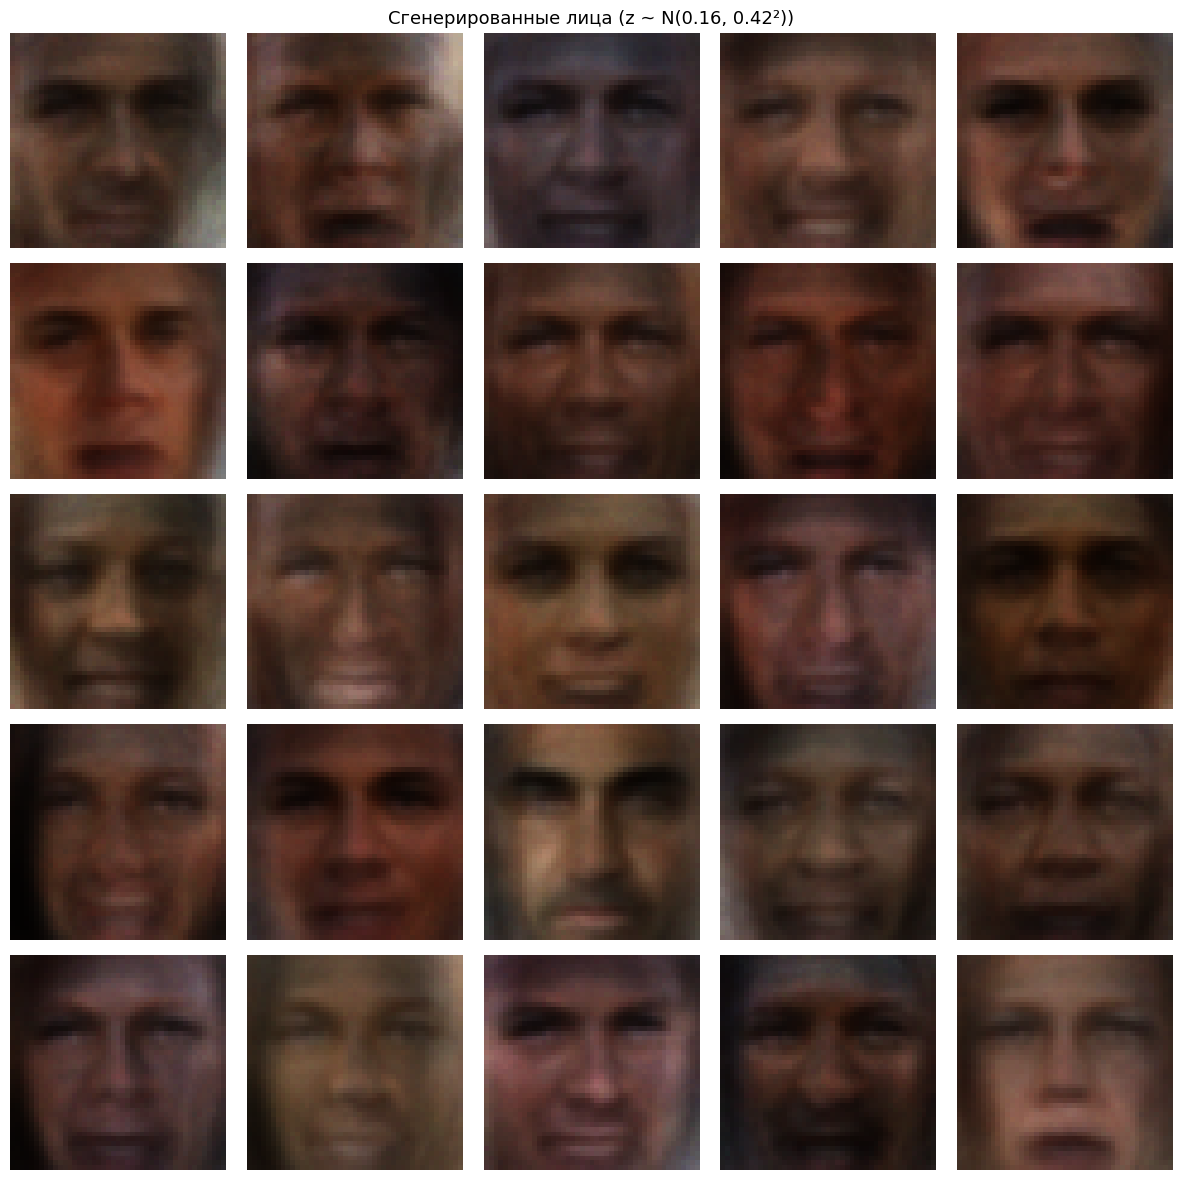

In [ ]:
autoencoder.eval()
with torch.no_grad():
    sample = X_val_t[:500].to(device)
    codes  = autoencoder.encoder(sample).cpu().numpy()

print(f"Латентные векторы — mean: {codes.mean():.4f}, std: {codes.std():.4f}")
print(f"min: {codes.min():.4f}, max: {codes.max():.4f}")

latent_mean = codes.mean()
latent_std  = codes.std()

z = np.random.randn(25, dim_code) * latent_std + latent_mean
z_tensor = torch.tensor(z, dtype=torch.float32).to(device)

autoencoder.eval()
with torch.no_grad():
    generated = autoencoder.decoder(z_tensor).cpu()  # (25, 3, 45, 45)

# 4. Выводим результат
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
plt.suptitle(f"Сгенерированные лица (z ~ N({latent_mean:.2f}, {latent_std:.2f}²))", fontsize=13)
plt.tight_layout()
os.makedirs("output", exist_ok=True)
plt.savefig("output/generated_faces.png", dpi=100)
plt.show()

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

Доступные атрибуты: ['Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth', 'Middle Aged', 'Senior', 'Black Hair'] ...
Значения 'Smiling': [-0.864989670524 0.798544268921 0.172817484002 ... 0.475018095929
 0.741652975024 -1.66797695067]
Улыбающихся в val: 837, используем: 100
Грустных в val:    1135, используем: 100
Smile vector — mean: -0.0083, std: 0.0636


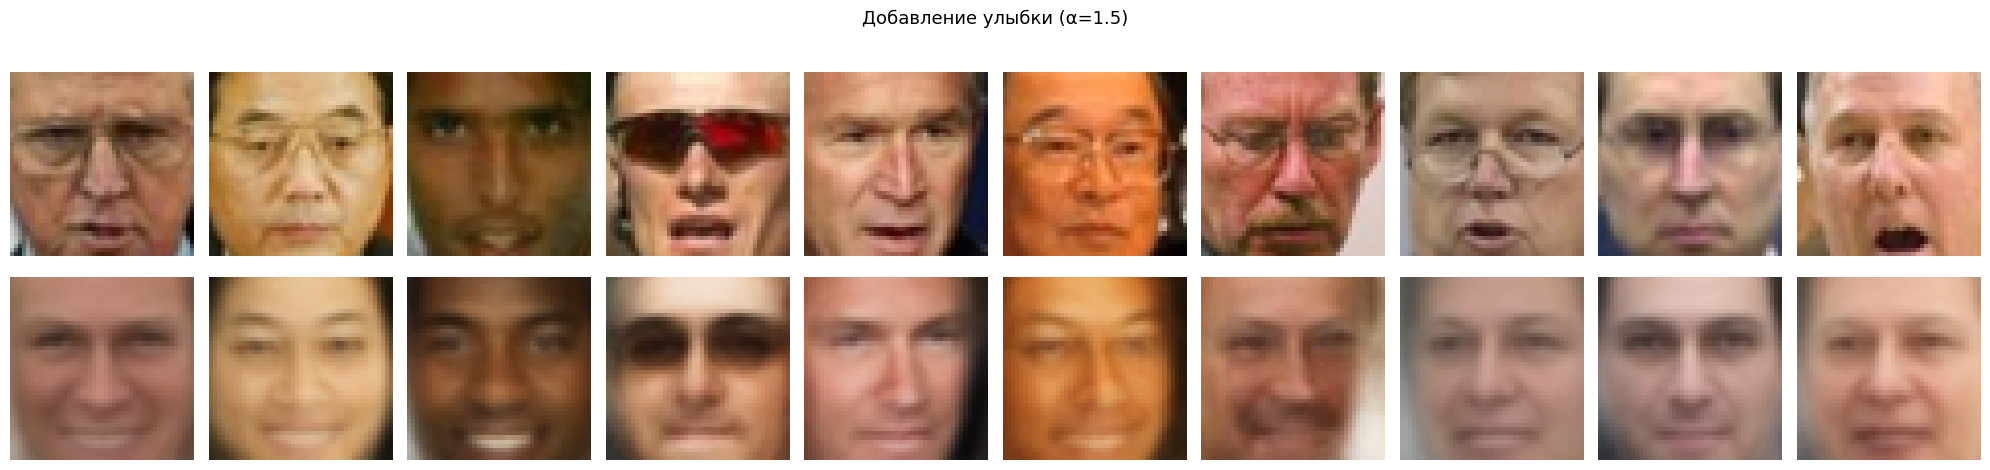

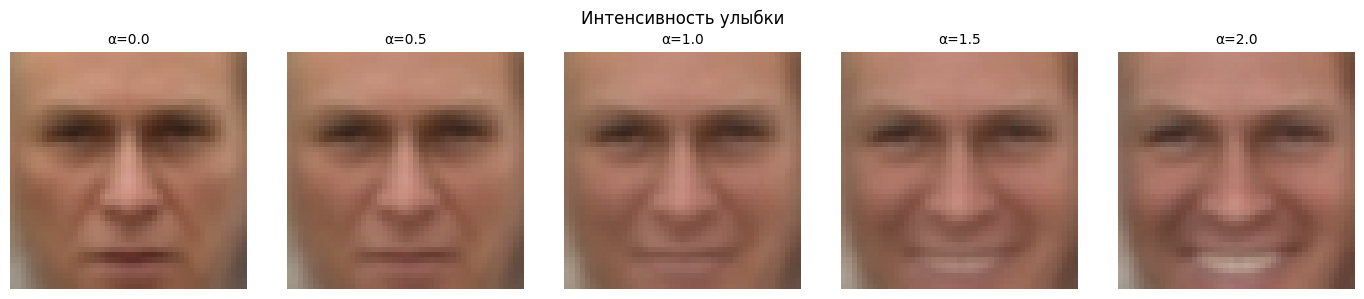

In [ ]:
smile_col = 'Smiling'
print("Доступные атрибуты:", list(attrs.columns[:10]), "...")
print(f"Значения '{smile_col}':", attrs[smile_col].unique())

val_attrs = attrs.iloc[val_idx].reset_index(drop=True)

smile_mask = val_attrs[smile_col] > 0
sad_mask   = val_attrs[smile_col] < 0

N = 100
smile_indices = np.where(smile_mask)[0][:N]
sad_indices   = np.where(sad_mask)[0][:N]

print(f"Улыбающихся в val: {smile_mask.sum()}, используем: {len(smile_indices)}")
print(f"Грустных в val:    {sad_mask.sum()}, используем: {len(sad_indices)}")

autoencoder.eval()
with torch.no_grad():
    smile_imgs = X_val_t[smile_indices].to(device)
    sad_imgs   = X_val_t[sad_indices].to(device)

    smile_codes = autoencoder.encoder(smile_imgs)
    sad_codes   = autoencoder.encoder(sad_imgs)

smile_vector = smile_codes.mean(dim=0, keepdim=True) - sad_codes.mean(dim=0, keepdim=True)
print(f"Smile vector — mean: {smile_vector.mean().item():.4f}, std: {smile_vector.std().item():.4f}")

ALPHA = 1.5

with torch.no_grad():
    test_sad_indices = np.where(sad_mask)[0][N:N+10]
    test_sad_imgs    = X_val_t[test_sad_indices].to(device)
    test_sad_codes   = autoencoder.encoder(test_sad_imgs)

    smiling_codes    = test_sad_codes + ALPHA * smile_vector
    reconstructed    = autoencoder.decoder(smiling_codes).cpu()
    originals_cpu    = test_sad_imgs.cpu()

fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for i in range(10):
    axes[0, i].imshow(originals_cpu[i].permute(1, 2, 0).clamp(0, 1))
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_ylabel("Оригинал", fontsize=10)

    axes[1, i].imshow(reconstructed[i].permute(1, 2, 0).clamp(0, 1))
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_ylabel("+ Улыбка", fontsize=10)

plt.suptitle(f"Добавление улыбки (α={ALPHA})", fontsize=13)
plt.tight_layout()
plt.savefig("output/smile_transfer.png", dpi=100)
plt.show()

alphas = [0.0, 0.5, 1.0, 1.5, 2.0]
test_person = X_val_t[test_sad_indices[0]:test_sad_indices[0]+1].to(device)

fig, axes = plt.subplots(1, len(alphas), figsize=(14, 3))
with torch.no_grad():
    code = autoencoder.encoder(test_person)
    for j, alpha in enumerate(alphas):
        out = autoencoder.decoder(code + alpha * smile_vector).cpu()
        axes[j].imshow(out[0].permute(1, 2, 0).clamp(0, 1))
        axes[j].set_title(f"α={alpha}", fontsize=10)
        axes[j].axis('off')

plt.suptitle("Интенсивность улыбки", fontsize=12)
plt.tight_layout()
plt.savefig("output/smile_intensity.png", dpi=100)
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [ ]:
from torchvision import transforms

batch_size = 32

train_dataset = datasets.MNIST(root='./mnist_data/', train=True,
                                transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False,
                                transform=transforms.ToTensor(), download=False)


train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                            batch_size=batch_size, shuffle=True)
test_loader  = torch.utils.data.DataLoader(dataset=test_dataset,
                                            batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")
print(f"Размер изображения MNIST: {train_dataset[0][0].shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 127MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 26.5MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 94.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]


Train batches: 1875, Test batches: 313
Размер изображения MNIST: torch.Size([1, 28, 28])


## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),    nn.BatchNorm1d(hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),   nn.BatchNorm1d(hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim//2),nn.BatchNorm1d(hidden_dim//2), nn.LeakyReLU(0.2),
        )
        self.fc_mu      = nn.Linear(hidden_dim//2, latent_dim)
        self.fc_logsigma = nn.Linear(hidden_dim//2, latent_dim)

        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim//2),  nn.BatchNorm1d(hidden_dim//2), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim//2, hidden_dim),  nn.BatchNorm1d(hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),     nn.BatchNorm1d(hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        x = x.reshape(x.size(0), -1)
        h = self.encoder_net(x)
        mu       = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + std * eps
        else:
            return mu

    def decode(self, z):
        reconstruction = self.decoder_net(z)
        return reconstruction.reshape(-1, 1, 28, 28)

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z            = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        return mu, logsigma, reconstruction

vae = VAE(input_dim=784, hidden_dim=512, latent_dim=32)
print(vae)
print(f"\nПараметров всего: {sum(p.numel() for p in vae.parameters()):,}")

x_test = torch.randn(4, 1, 28, 28)
mu, logsigma, recon = vae(x_test)
print(f"\nmu:     {mu.shape}")
print(f"logsigma: {logsigma.shape}")
print(f"recon:  {recon.shape}")

VAE(
  (encoder_net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
  )
  (fc_mu): Linear(in_features=256, out_features=32, bias=True)
  (fc_logsigma): Linear(in_features=256, out_features=32, bias=True)
  (decoder_net): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=256, out_f

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [ ]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + 2 * logsigma - mu.pow(2) - torch.exp(2 * logsigma))
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = nn.BCELoss(reduction='sum')
    return loss(reconstruction, x)

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) - log_likelihood(x, reconstruction)

И обучим модель:

In [ ]:
vae = VAE(input_dim=784, hidden_dim=512, latent_dim=64).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

Epoch [ 1/35]  train=-68577.90  test=-68540.17


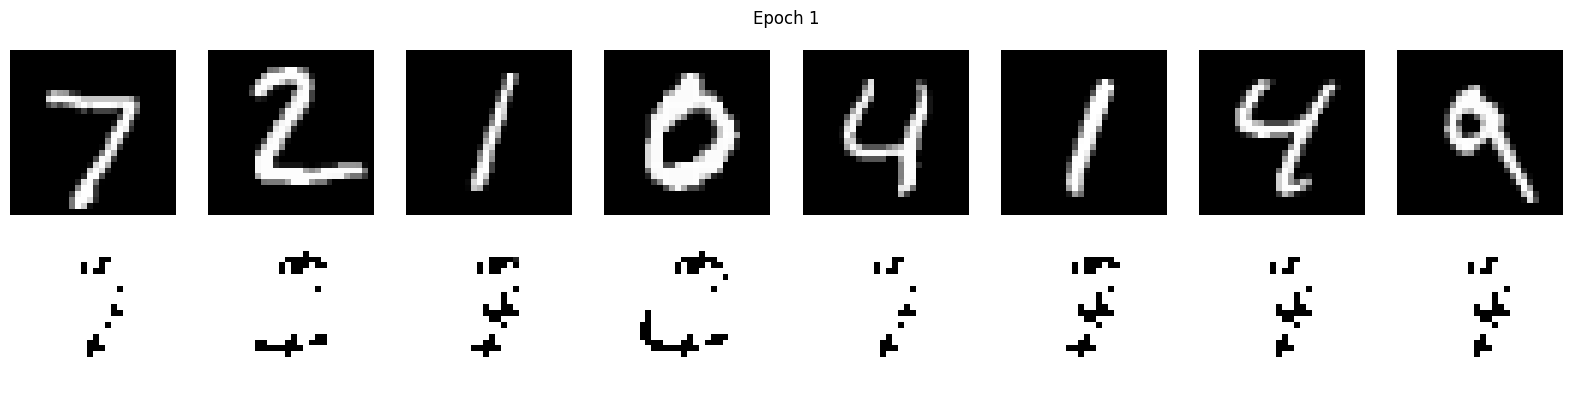

Epoch [ 2/35]  train=-68588.07  test=-68557.76
Epoch [ 3/35]  train=-68596.55  test=-68569.88
Epoch [ 4/35]  train=-68613.22  test=-68582.59
Epoch [ 5/35]  train=-68626.54  test=-68589.24


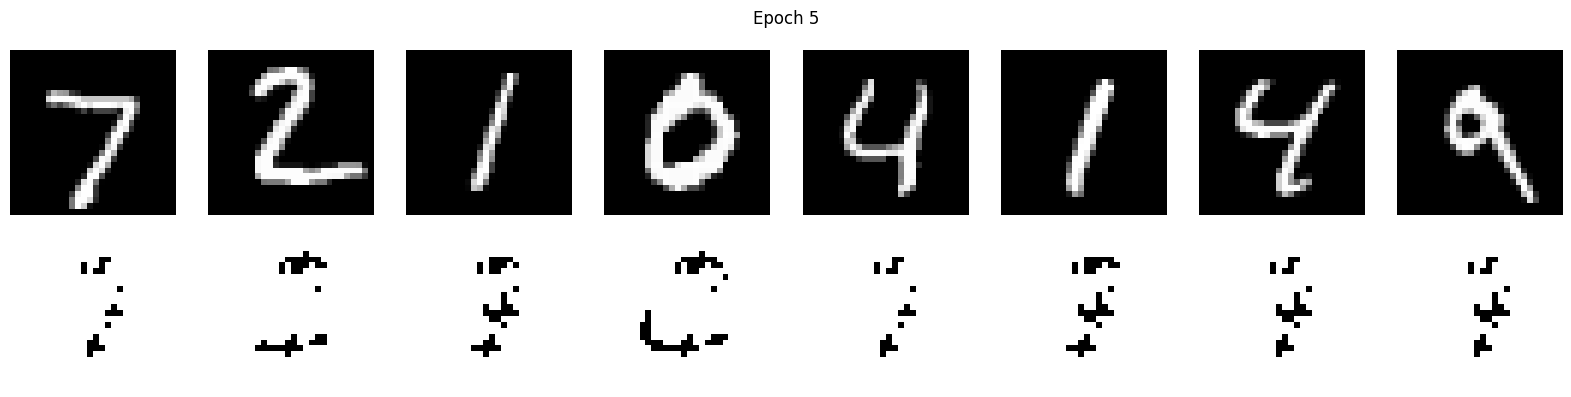

Epoch [ 6/35]  train=-68635.25  test=-68616.72
Epoch [ 7/35]  train=-68648.23  test=-68613.07
Epoch [ 8/35]  train=-68651.85  test=-68614.27
Epoch [ 9/35]  train=-68663.62  test=-68627.25
Epoch [10/35]  train=-68664.39  test=-68633.43


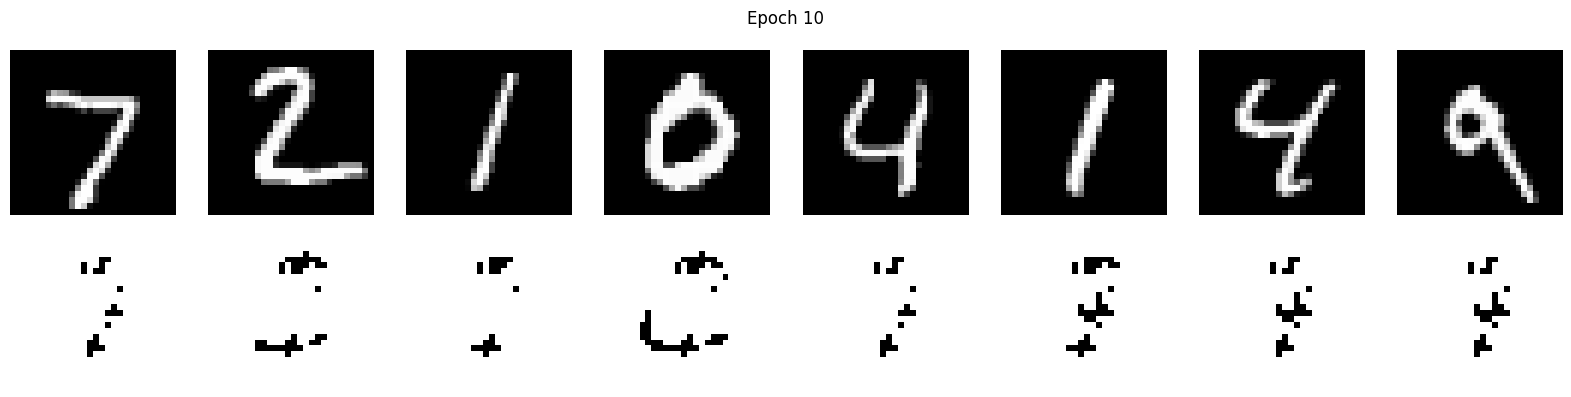

Epoch [11/35]  train=-68657.37  test=-68647.67
Epoch [12/35]  train=-68672.46  test=-68655.01
Epoch [13/35]  train=-68678.75  test=-68653.34
Epoch [14/35]  train=-68690.92  test=-68676.72
Epoch [15/35]  train=-68697.98  test=-68687.68


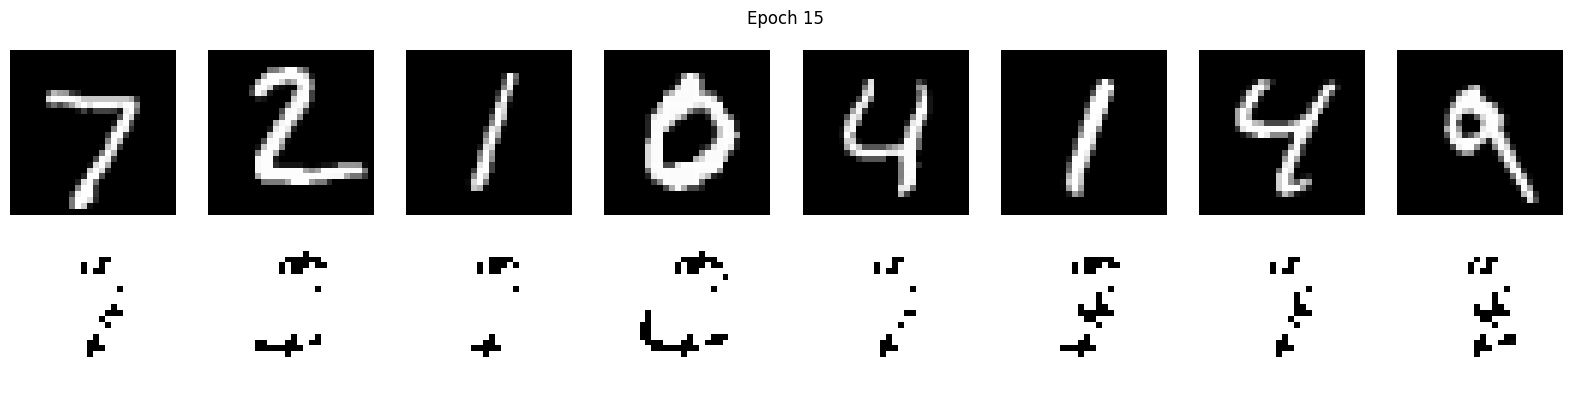

Epoch [16/35]  train=-68708.09  test=-68700.39
Epoch [17/35]  train=-68720.52  test=-68695.73
Epoch [18/35]  train=-68723.64  test=-68715.84
Epoch [19/35]  train=-68733.96  test=-68718.93
Epoch [20/35]  train=-68744.74  test=-68704.12


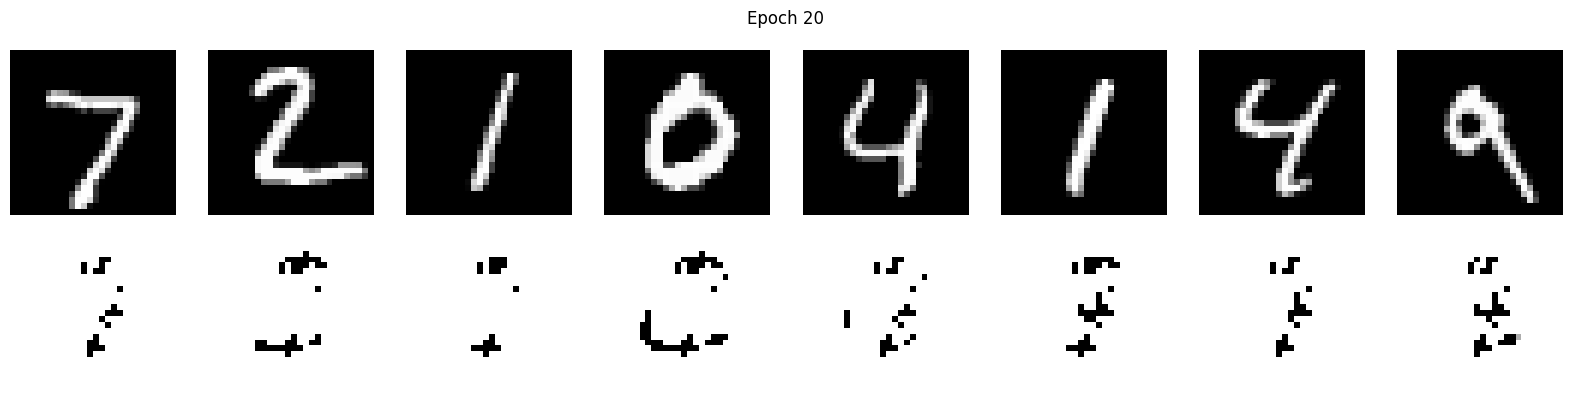

Epoch [21/35]  train=-68741.26  test=-68721.32
Epoch [22/35]  train=-68743.27  test=-68723.94
Epoch [23/35]  train=-68756.43  test=-68743.13
Epoch [24/35]  train=-68764.26  test=-68748.95
Epoch [25/35]  train=-68770.97  test=-68777.83


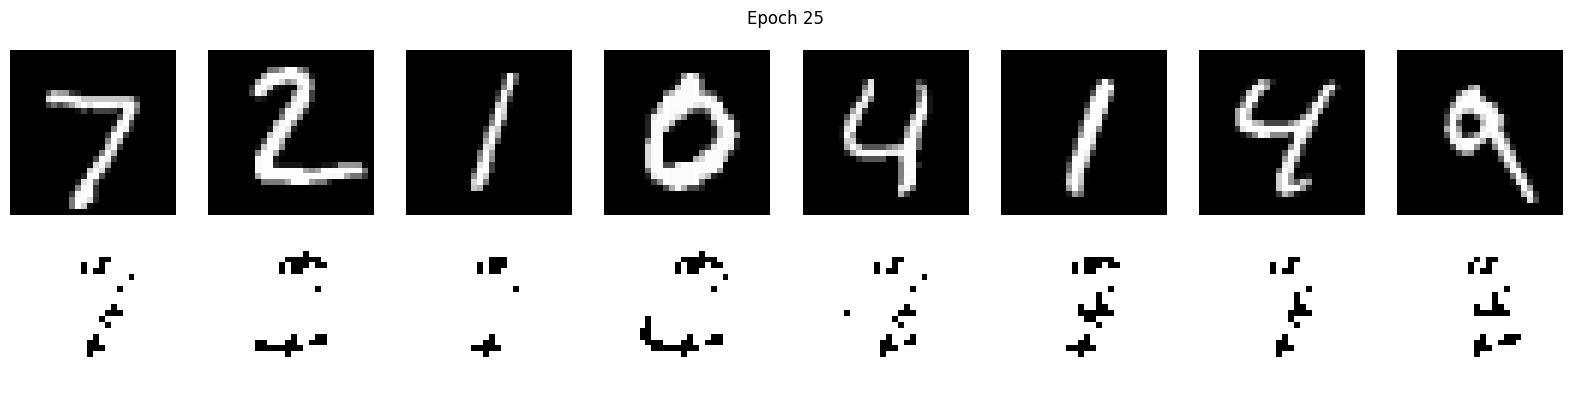

Epoch [26/35]  train=-68773.82  test=-68766.44
Epoch [27/35]  train=-68787.70  test=-68763.72
Epoch [28/35]  train=-68791.72  test=-68775.19
Epoch [29/35]  train=-68798.80  test=-68789.46
Epoch [30/35]  train=-68801.63  test=-68786.61


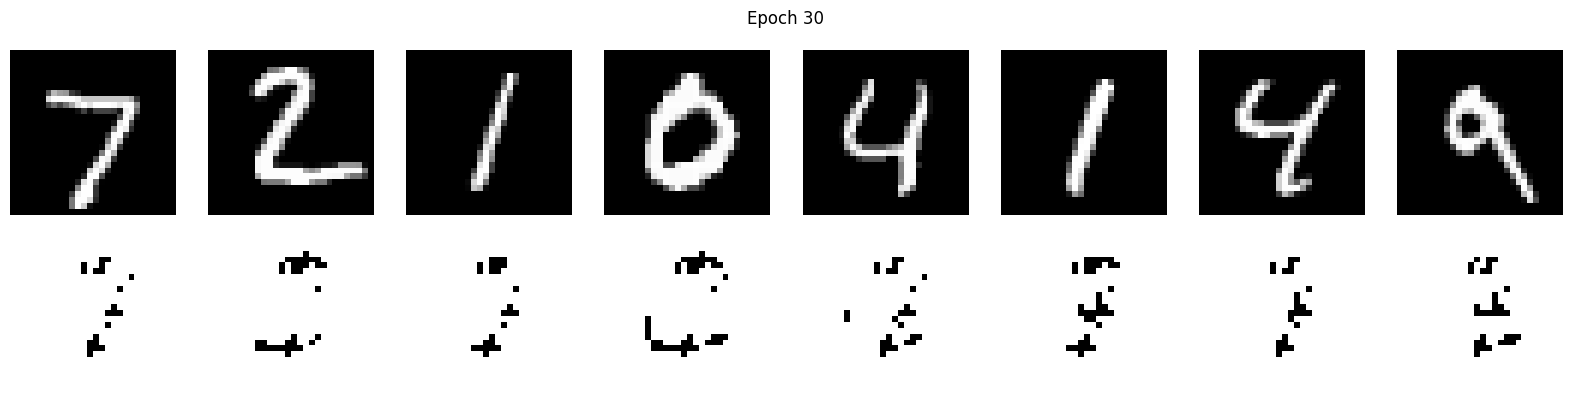

Epoch [31/35]  train=-68808.22  test=-68792.34
Epoch [32/35]  train=-68808.96  test=-68784.50
Epoch [33/35]  train=-68814.50  test=-68785.12
Epoch [34/35]  train=-68822.44  test=-68794.08
Epoch [35/35]  train=-68821.68  test=-68784.36


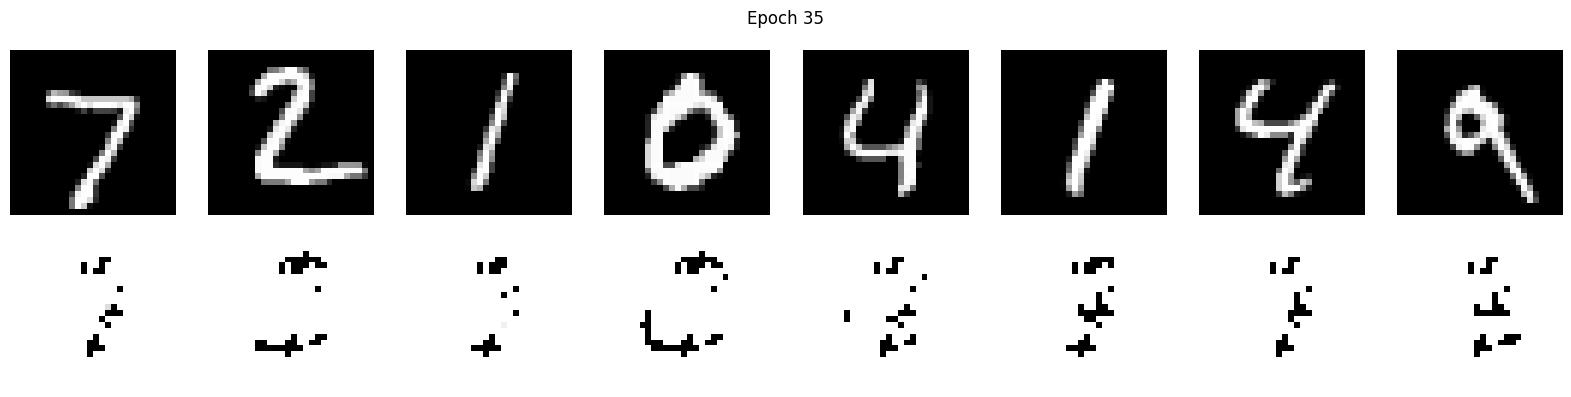

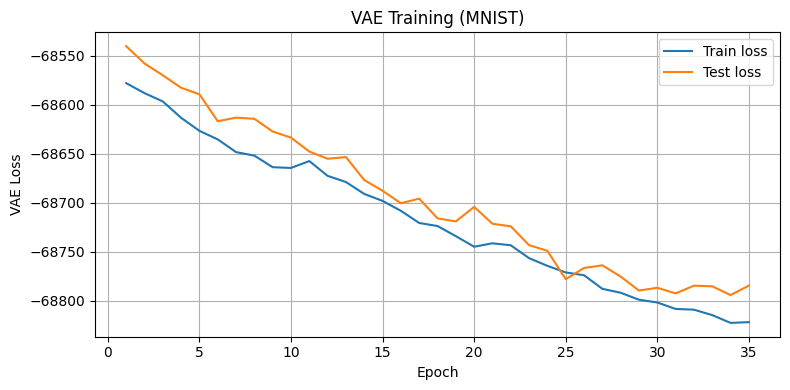

In [ ]:
EPOCHS = 35
train_losses, test_losses = [], []

os.makedirs("output", exist_ok=True)

viz_batch, _ = next(iter(test_loader))
viz_batch = viz_batch[:8].to(device)

for epoch in range(1, EPOCHS + 1):
    vae.train()
    running_loss = 0.0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        mu, logsigma, recon = vae(x)
        loss = loss_vae(x, mu, logsigma, recon)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    vae.eval()
    with torch.no_grad():
        test_loss = sum(
            loss_vae(x.to(device), *vae(x.to(device))[:2], vae(x.to(device))[2]).item()
            for x, _ in test_loader
        ) / len(test_loader.dataset)
    test_losses.append(test_loss)

    print(f"Epoch [{epoch:>2}/{EPOCHS}]  train={train_loss:.2f}  test={test_loss:.2f}")

    if epoch % 5 == 0 or epoch == 1:
        vae.eval()
        with torch.no_grad():
            _, _, recons = vae(viz_batch)

        fig, axes = plt.subplots(2, 8, figsize=(16, 4))
        for i in range(8):
            axes[0, i].imshow(viz_batch[i].cpu().squeeze(), cmap='gray')
            axes[0, i].axis('off')
            axes[1, i].imshow(recons[i].cpu().squeeze(), cmap='gray')
            axes[1, i].axis('off')
        axes[0, 0].set_ylabel("Original", fontsize=9)
        axes[1, 0].set_ylabel("Recon", fontsize=9)
        plt.suptitle(f"Epoch {epoch}", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"output/vae_recon_epoch_{epoch:02d}.png", dpi=100)
        plt.show()

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train loss')
plt.plot(range(1, EPOCHS+1), test_losses,  label='Test loss')
plt.xlabel("Epoch"); plt.ylabel("VAE Loss")
plt.title("VAE Training (MNIST)"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig("output/vae_loss_curve.png", dpi=100)
plt.show()

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

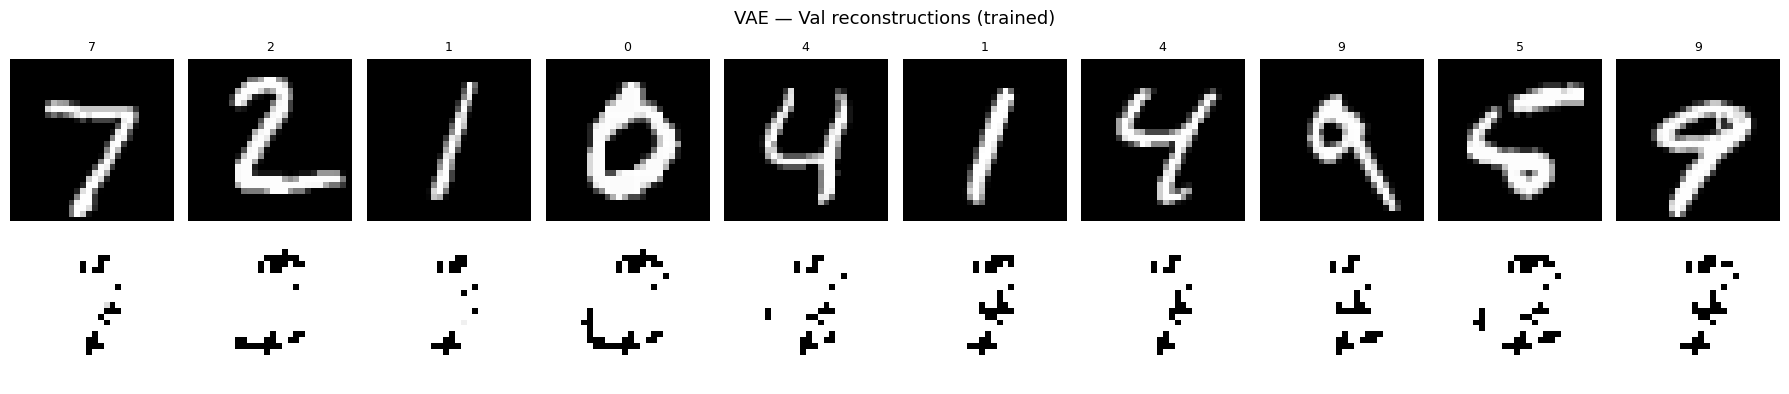

In [ ]:
X_VIZ = 10
vae.eval()

viz_imgs, viz_labels = next(iter(test_loader))
viz_imgs = viz_imgs[:X_VIZ].to(device)

with torch.no_grad():
    _, _, recons = vae(viz_imgs)

fig, axes = plt.subplots(2, X_VIZ, figsize=(X_VIZ * 1.8, 4))
for i in range(X_VIZ):
    axes[0, i].imshow(viz_imgs[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(str(viz_labels[i].item()), fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(recons[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
plt.suptitle("VAE — Val reconstructions (trained)", fontsize=13)
plt.tight_layout()
plt.savefig("output/vae_final_reconstructions.png", dpi=100)
plt.show()

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

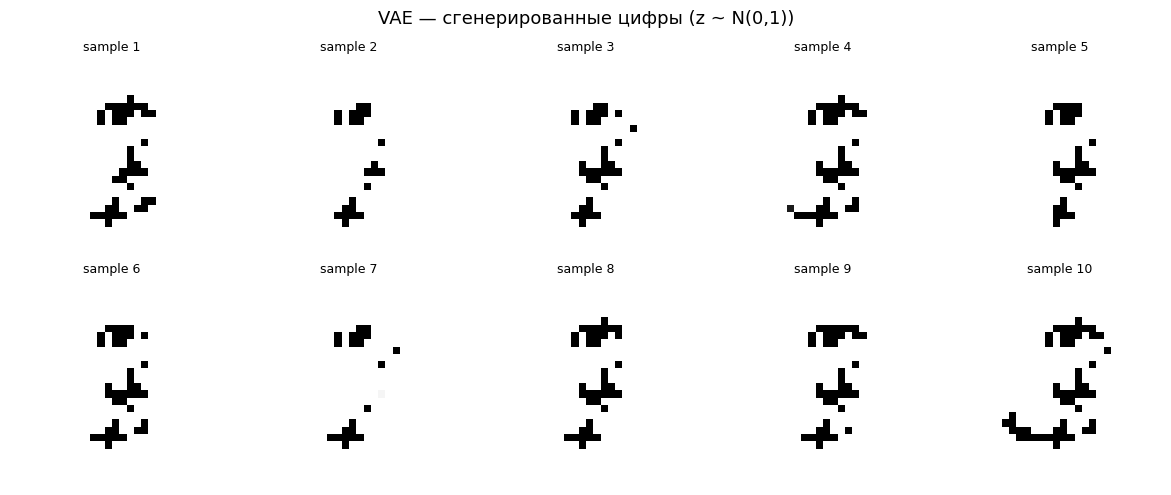

In [ ]:
z = np.random.normal(0, 1, (10, 32))
z_tensor = torch.tensor(z, dtype=torch.float32).to(device)

vae.eval()
with torch.no_grad():
    generated = vae.decode(z_tensor).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap='gray')
    ax.axis('off')
    ax.set_title(f"sample {i+1}", fontsize=9)

plt.suptitle("VAE — сгенерированные цифры (z ~ N(0,1))", fontsize=13)
plt.tight_layout()
plt.savefig("output/vae_generated.png", dpi=100)
plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

Codes shape: (10000, 32), Labels shape: (10000,)
Запускаем t-SNE (может занять ~1-2 мин)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 10000 samples in 0.989s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.428306
[t-SNE] KL divergence after 250 iterations with early exaggeration: 85.743774
[t-SNE] KL divergence after 1000 iterations: 1.514461
t-SNE готов: (10000, 2)


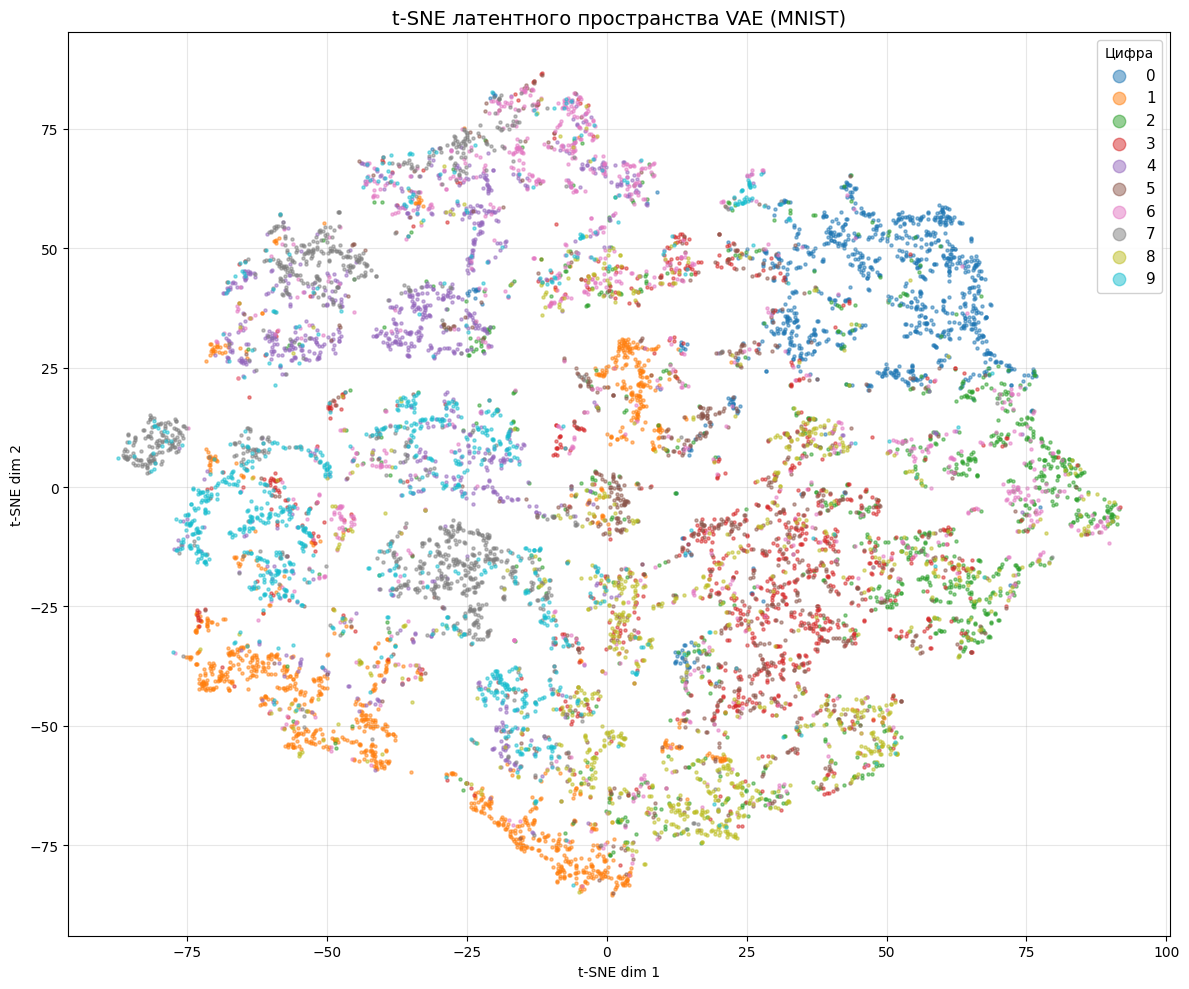

In [ ]:
from sklearn.manifold import TSNE

vae.eval()
all_codes, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, logsigma = vae.encode(x)
        all_codes.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_codes  = np.concatenate(all_codes,  axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Codes shape: {all_codes.shape}, Labels shape: {all_labels.shape}")

print("Запускаем t-SNE (может занять ~1-2 мин)...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=1)
codes_2d = tsne.fit_transform(all_codes)
print(f"t-SNE готов: {codes_2d.shape}")

COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

fig, ax = plt.subplots(figsize=(12, 10))

for digit in range(10):
    mask = all_labels == digit
    ax.scatter(
        codes_2d[mask, 0],
        codes_2d[mask, 1],
        c=[COLORS[digit]],
        label=str(digit),
        alpha=0.5,
        s=5,
        rasterized=True
    )

ax.legend(title="Цифра", markerscale=4, fontsize=11,
          loc='upper right', framealpha=0.9)
ax.set_title("t-SNE латентного пространства VAE (MNIST)", fontsize=14)
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output/vae_tsne.png", dpi=150)
plt.show()

Что вы думаете о виде латентного представления?

Кластеры есть, но сильно пееремешаны, нет четких границ, но kl хорошее, структура не совсем хаотична, но структура ленточная больше, а не облако.

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [ ]:
NUM_CLASSES = 10
LATENT_DIM  = 32
HIDDEN_DIM  = 512
INPUT_DIM   = 784

class CVAE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM,
                 latent_dim=LATENT_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.latent_dim  = latent_dim
        self.num_classes = num_classes

        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim + num_classes, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2), nn.LeakyReLU(0.2),
        )
        self.fc_mu       = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logsigma = nn.Linear(hidden_dim // 2, latent_dim)

        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim + num_classes, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def _one_hot(self, class_num):
        """Конвертируем метки классов в one-hot на том же устройстве"""
        return F.one_hot(class_num, num_classes=self.num_classes).float()

    def encode(self, x, class_num):
        one_hot = self._one_hot(class_num)
        x_flat  = x.reshape(x.size(0), -1)
        x_cond  = torch.cat([x_flat, one_hot], dim=1)
        h       = self.encoder_net(x_cond)
        mu       = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        return mu, logsigma, class_num

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + std * eps
        else:
            return mu

    def decode(self, z, class_num):
        one_hot     = self._one_hot(class_num)
        z_cond      = torch.cat([z, one_hot], dim=1)
        out         = self.decoder_net(z_cond)
        reconstruction = out.reshape(-1, 1, 28, 28)
        return reconstruction

    def forward(self, x, class_num):
        mu, logsigma, class_num = self.encode(x, class_num)
        z             = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z, class_num)
        return mu, logsigma, reconstruction


cvae = CVAE().to(device)
x_test = torch.randn(4, 1, 28, 28).to(device)
y_test = torch.tensor([0, 3, 7, 8]).to(device)
mu, logsigma, recon = cvae(x_test, y_test)
print(f"mu:     {mu.shape}")
print(f"logsigma: {logsigma.shape}")
print(f"recon:  {recon.shape}")
print(f"\nПараметров всего: {sum(p.numel() for p in cvae.parameters()):,}")

mu:     torch.Size([4, 32])
logsigma: torch.Size([4, 32])
recon:  torch.Size([4, 1, 28, 28])

Параметров всего: 1,630,032


### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

Epoch [ 1/20]  train=-64061.80  test=-67332.25
Epoch [ 2/20]  train=-67523.82  test=-67464.58
Epoch [ 3/20]  train=-67560.59  test=-67541.93
Epoch [ 4/20]  train=-67612.99  test=-67568.06
Epoch [ 5/20]  train=-67676.72  test=-67584.43
Epoch [ 6/20]  train=-67721.70  test=-67673.12
Epoch [ 7/20]  train=-67823.81  test=-67797.84
Epoch [ 8/20]  train=-67915.12  test=-67818.53
Epoch [ 9/20]  train=-67958.62  test=-67848.55
Epoch [10/20]  train=-67935.22  test=-67840.90
Epoch [11/20]  train=-67963.09  test=-67827.94
Epoch [12/20]  train=-67914.84  test=-67818.92
Epoch [13/20]  train=-67890.10  test=-67802.24
Epoch [14/20]  train=-67893.03  test=-67789.19
Epoch [15/20]  train=-67915.33  test=-67838.03
Epoch [16/20]  train=-67924.13  test=-67818.38
Epoch [17/20]  train=-67928.14  test=-67863.07
Epoch [18/20]  train=-67951.64  test=-67896.09
Epoch [19/20]  train=-67965.89  test=-67904.71
Epoch [20/20]  train=-67985.58  test=-67913.87


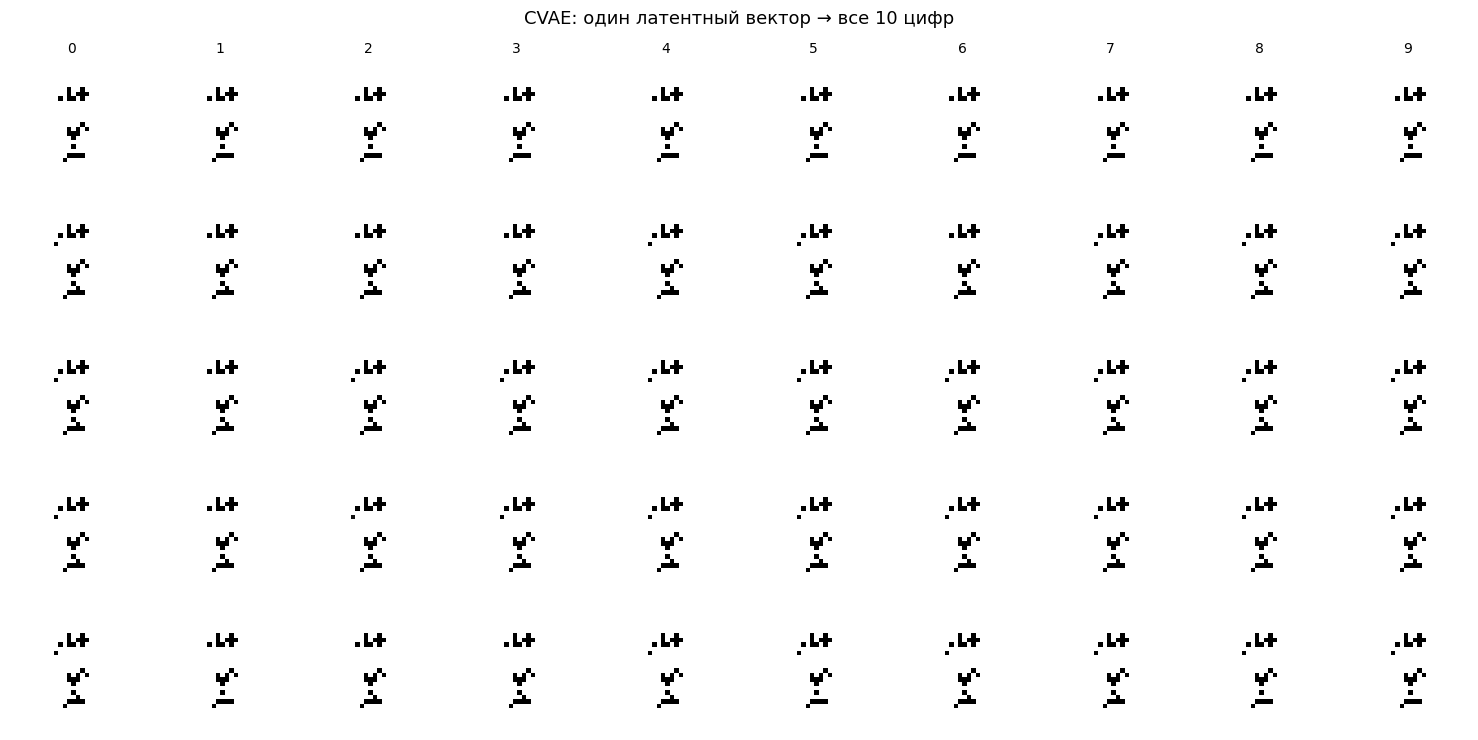

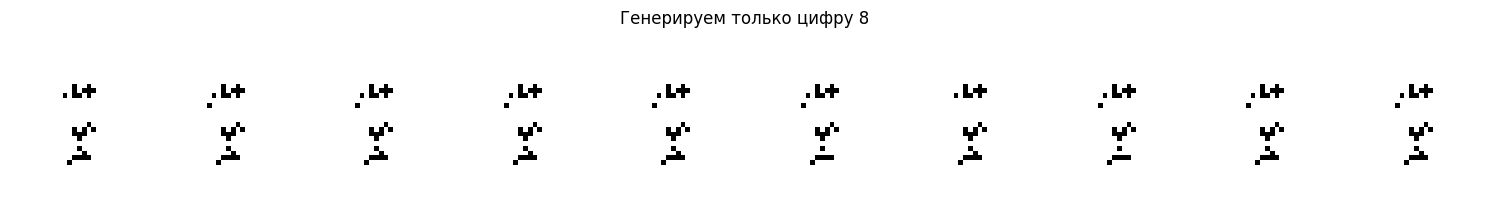

In [ ]:
cvae = CVAE().to(device)
optimizer_cvae = optim.Adam(cvae.parameters(), lr=1e-3)

EPOCHS = 20
train_losses_cvae, test_losses_cvae = [], []

for epoch in range(1, EPOCHS + 1):
    cvae.train()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer_cvae.zero_grad()
        mu, logsigma, recon = cvae(x, y)
        loss = loss_vae(x, mu, logsigma, recon)
        loss.backward()
        optimizer_cvae.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader.dataset)
    train_losses_cvae.append(train_loss)

    cvae.eval()
    with torch.no_grad():
        test_loss = sum(
            loss_vae(x.to(device), *cvae(x.to(device), y.to(device))[:2],
                     cvae(x.to(device), y.to(device))[2]).item()
            for x, y in test_loader
        ) / len(test_loader.dataset)
    test_losses_cvae.append(test_loss)

    print(f"Epoch [{epoch:>2}/{EPOCHS}]  train={train_loss:.2f}  test={test_loss:.2f}")

cvae.eval()

N_SAMPLES = 5

with torch.no_grad():
    fig, axes = plt.subplots(N_SAMPLES, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, N_SAMPLES * 1.5))

    for row in range(N_SAMPLES):
        z = torch.randn(1, LATENT_DIM).to(device)
        z_rep = z.repeat(NUM_CLASSES, 1)
        labels = torch.arange(NUM_CLASSES).to(device)

        generated = cvae.decode(z_rep, labels).cpu()

        for col in range(NUM_CLASSES):
            axes[row, col].imshow(generated[col].squeeze(), cmap='gray')
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(str(col), fontsize=10)

    axes[0, 0].set_ylabel("z₁", fontsize=9, rotation=0, labelpad=20)

plt.suptitle("CVAE: один латентный вектор → все 10 цифр", fontsize=13)
plt.tight_layout()
plt.savefig("output/cvae_sampling.png", dpi=150)
plt.show()

TARGET_DIGIT = 8
N = 10

with torch.no_grad():
    z      = torch.randn(N, LATENT_DIM).to(device)
    labels = torch.full((N,), TARGET_DIGIT, dtype=torch.long).to(device)
    imgs   = cvae.decode(z, labels).cpu()

fig, axes = plt.subplots(1, N, figsize=(N * 1.5, 2))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle(f"Генерируем только цифру {TARGET_DIGIT}", fontsize=12)
plt.tight_layout()
plt.savefig(f"output/cvae_digit_{TARGET_DIGIT}.png", dpi=150)
plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

CVAE codes: (10000, 32)
Запускаем t-SNE для CVAE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 0.976s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.035058
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.579292
[t-SNE] KL divergence after

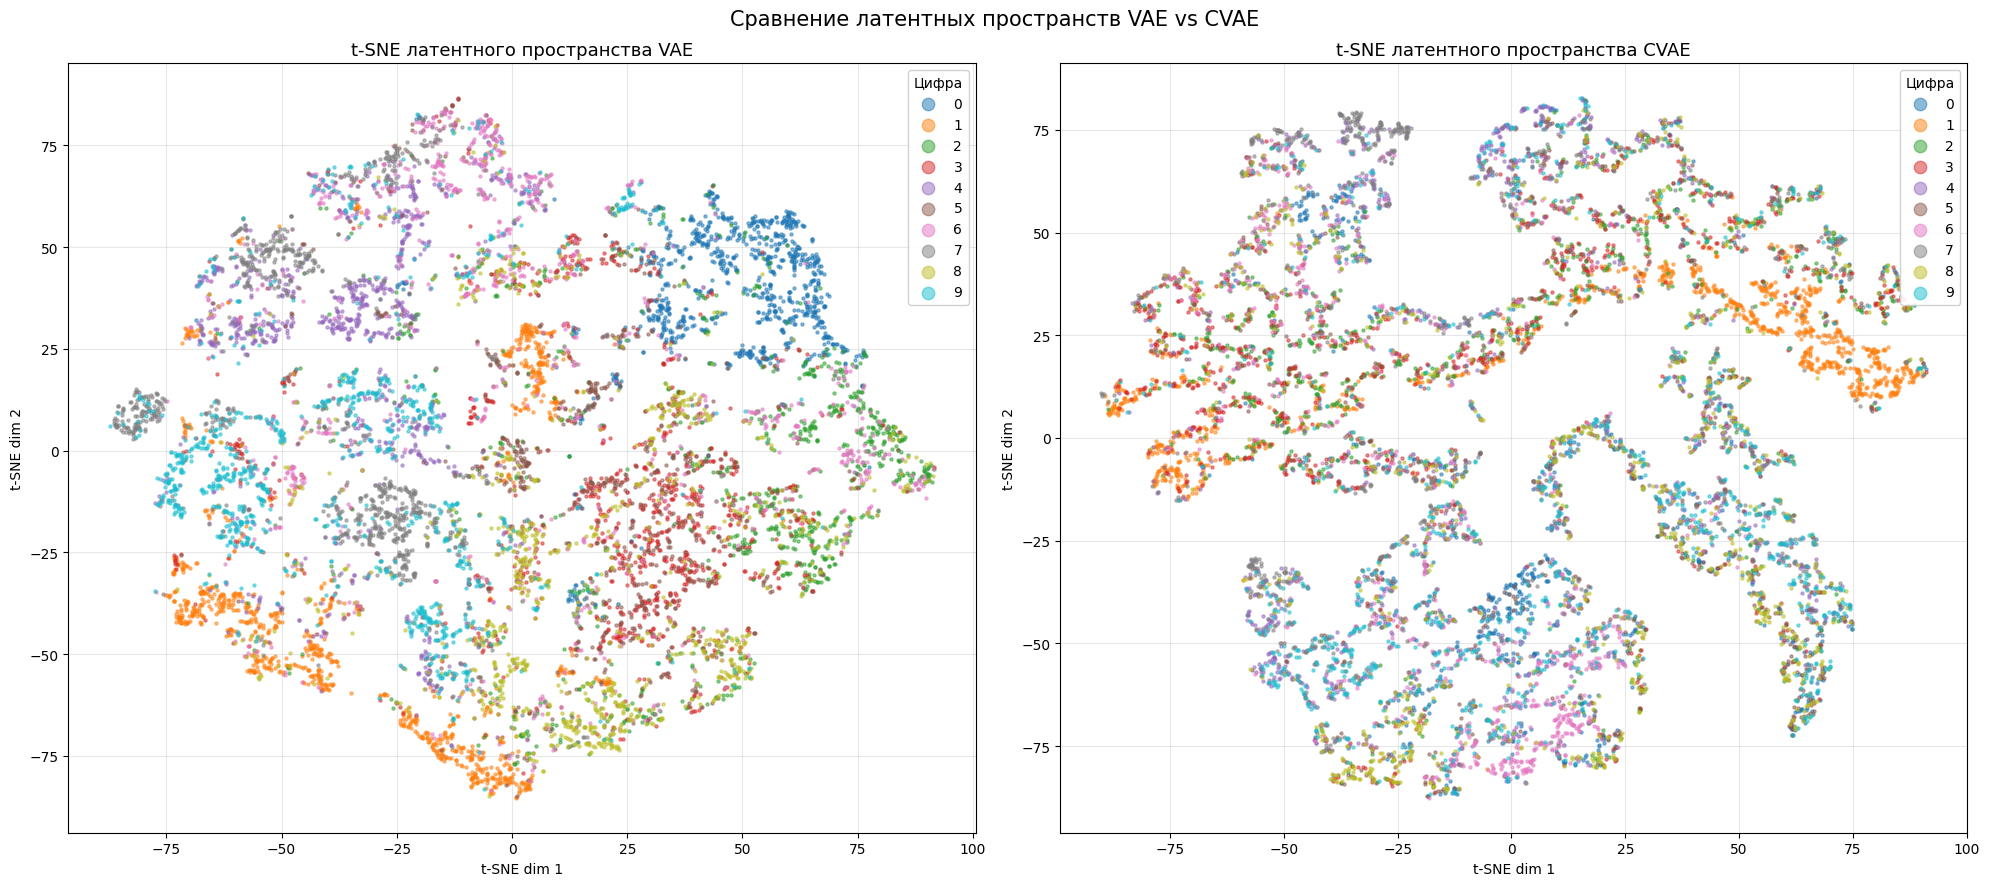

In [ ]:
cvae.eval()
cvae_codes, cvae_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        mu, logsigma, _ = cvae.encode(x, y)
        cvae_codes.append(mu.cpu().numpy())
        cvae_labels.append(y.cpu().numpy())

cvae_codes  = np.concatenate(cvae_codes,  axis=0)
cvae_labels = np.concatenate(cvae_labels, axis=0)
print(f"CVAE codes: {cvae_codes.shape}")

print("Запускаем t-SNE для CVAE...")
tsne_cvae = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, verbose=1)
cvae_codes_2d = tsne_cvae.fit_transform(cvae_codes)
print(f"t-SNE готов: {cvae_codes_2d.shape}")

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, codes_2d, labels, title in zip(
    axes,
    [codes_2d,      cvae_codes_2d],
    [all_labels,    cvae_labels],
    ["VAE",         "CVAE"]
):
    for digit in range(10):
        mask = labels == digit
        ax.scatter(
            codes_2d[mask, 0],
            codes_2d[mask, 1],
            c=[COLORS[digit]],
            label=str(digit),
            alpha=0.5,
            s=5,
            rasterized=True
        )
    ax.set_title(f"t-SNE латентного пространства {title}", fontsize=13)
    ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
    ax.legend(title="Цифра", markerscale=4, fontsize=10,
              loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Сравнение латентных пространств VAE vs CVAE", fontsize=15)
plt.tight_layout()
plt.savefig("output/vae_vs_cvae_tsne.png", dpi=150)
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

cvae вообще не кластеризовался практичеки, пучки есть, не тамк размыто, но это контуры смеси а не отдельных классов.

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

Train noisy: torch.Size([11171, 3, 45, 45]), min=0.00, max=1.00


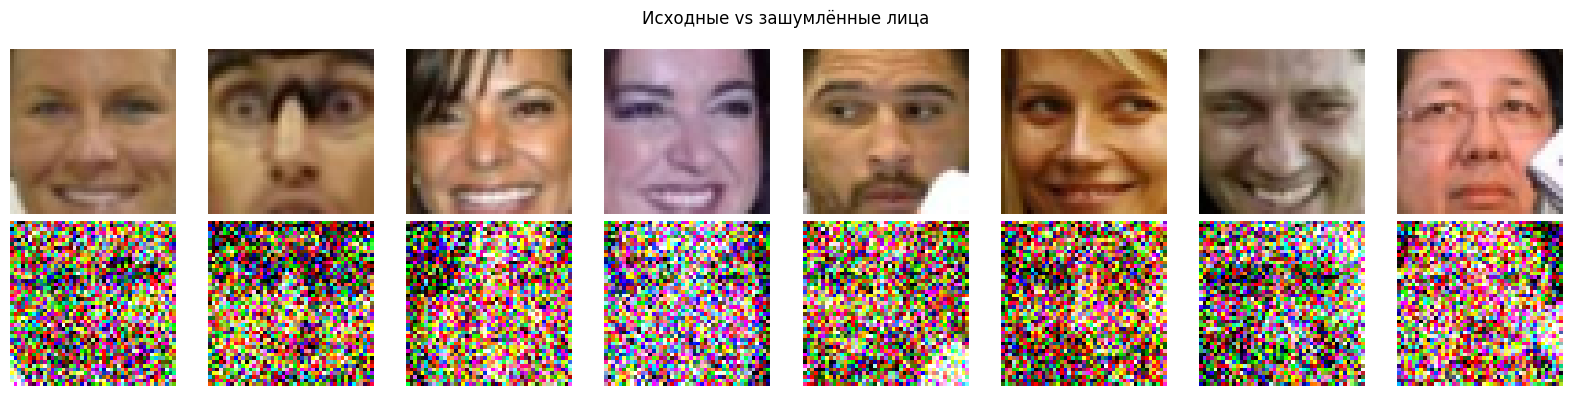

In [ ]:
noise_factor = 0.5

X_train_noisy = (X_train_t + noise_factor * torch.randn_like(X_train_t)).clamp(0, 1)
X_val_noisy   = (X_val_t   + noise_factor * torch.randn_like(X_val_t)).clamp(0, 1)

print(f"Train noisy: {X_train_noisy.shape}, min={X_train_noisy.min():.2f}, max={X_train_noisy.max():.2f}")

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(X_train_t[i].permute(1,2,0).clamp(0,1));  axes[0, i].axis('off')
    axes[1, i].imshow(X_train_noisy[i].permute(1,2,0).clamp(0,1)); axes[1, i].axis('off')
axes[0,0].set_ylabel("Оригинал",  fontsize=9)
axes[1,0].set_ylabel("Зашумлённый", fontsize=9)
plt.suptitle("Исходные vs зашумлённые лица", fontsize=12)
plt.tight_layout(); plt.savefig("output/noisy_samples.png", dpi=100); plt.show()

Epoch [ 1/25]  train=0.0270  val=0.0258
Epoch [ 5/25]  train=0.0124  val=0.0125
Epoch [10/25]  train=0.0109  val=0.0107
Epoch [15/25]  train=0.0097  val=0.0098
Epoch [20/25]  train=0.0085  val=0.0090
Epoch [25/25]  train=0.0081  val=0.0087


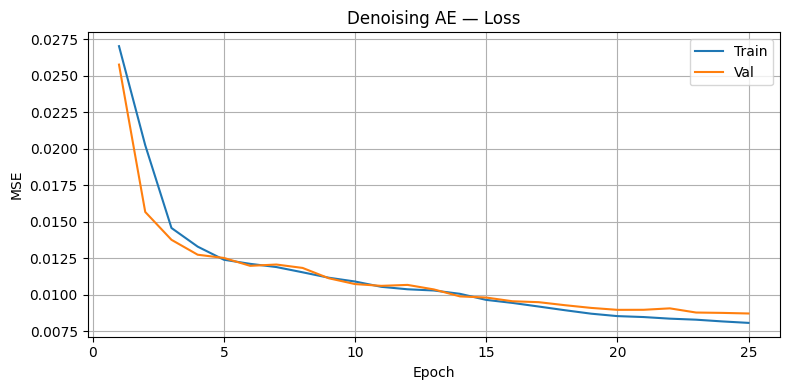

In [ ]:
train_denoising = data_utils.TensorDataset(X_train_noisy, X_train_t)
val_denoising   = data_utils.TensorDataset(X_val_noisy,   X_val_t)

train_loader_dn = data_utils.DataLoader(train_denoising, batch_size=64, shuffle=True,  drop_last=True)
val_loader_dn   = data_utils.DataLoader(val_denoising,   batch_size=64, shuffle=False)

denoising_ae = Autoencoder().to(device)
optimizer_dn  = optim.Adam(denoising_ae.parameters(), lr=1e-3)
criterion_dn  = nn.MSELoss()

EPOCHS = 25
train_losses_dn, val_losses_dn = [], []

for epoch in range(1, EPOCHS + 1):
    # TRAIN:
    denoising_ae.train()
    running = 0.0
    for x_noisy, x_clean in train_loader_dn:
        x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
        optimizer_dn.zero_grad()
        recon = denoising_ae(x_noisy)           # подаём зашумлённый
        loss  = criterion_dn(recon, x_clean)    # сравниваем с чистым!
        loss.backward()
        optimizer_dn.step()
        running += loss.item()
    train_loss = running / len(train_loader_dn)
    train_losses_dn.append(train_loss)

    # VAL
    denoising_ae.eval()
    with torch.no_grad():
        val_loss = sum(criterion_dn(denoising_ae(xn.to(device)), xc.to(device)).item()
                       for xn, xc in val_loader_dn) / len(val_loader_dn)
    val_losses_dn.append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:>2}/{EPOCHS}]  train={train_loss:.4f}  val={val_loss:.4f}")

plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS+1), train_losses_dn, label='Train')
plt.plot(range(1, EPOCHS+1), val_losses_dn,   label='Val')
plt.title("Denoising AE — Loss"); plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("output/denoising_loss.png", dpi=100); plt.show()

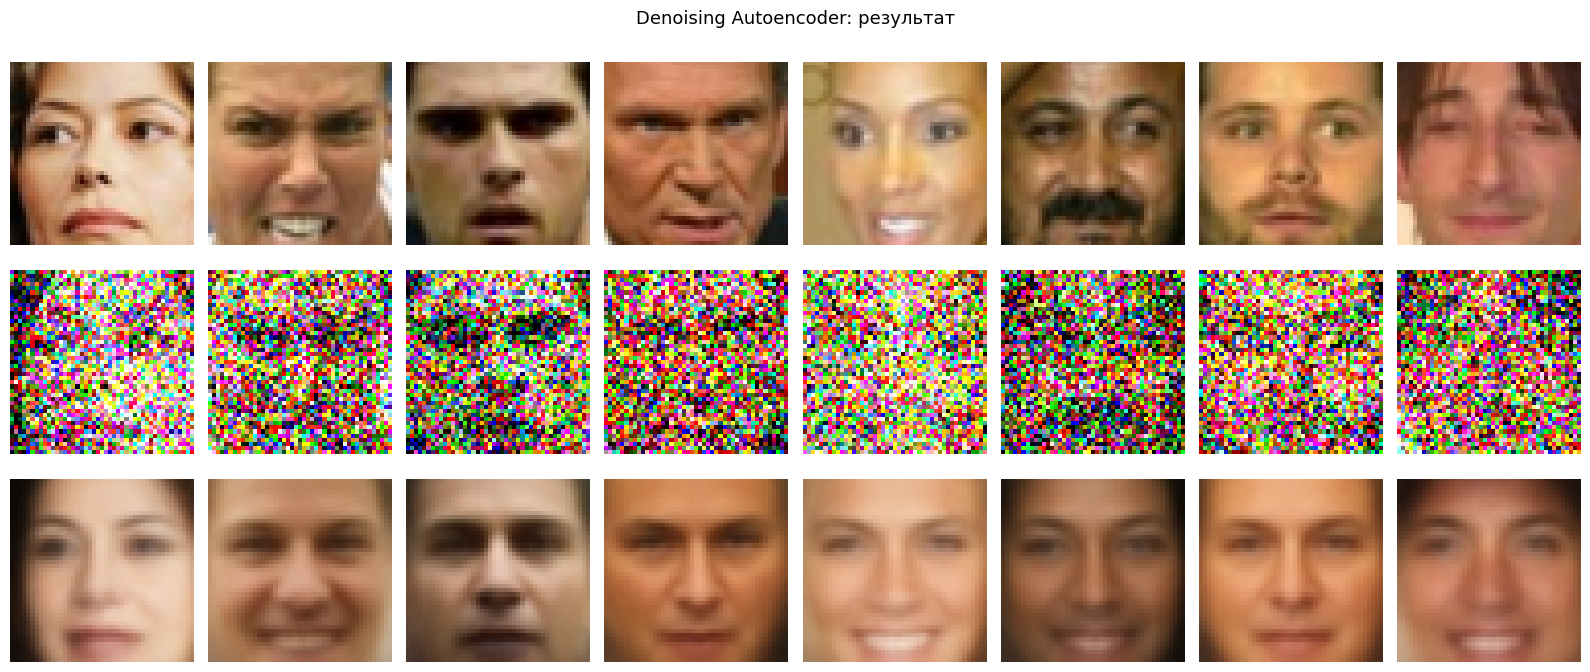

In [ ]:
denoising_ae.eval()
N = 8
x_noisy_sample = X_val_noisy[:N].to(device)
x_clean_sample = X_val_t[:N]

with torch.no_grad():
    denoised = denoising_ae(x_noisy_sample).cpu()

fig, axes = plt.subplots(3, N, figsize=(N*2, 7))
titles = ["Оригинал", "Зашумлённый", "Очищенный (AE)"]
data   = [x_clean_sample, x_noisy_sample.cpu(), denoised]

for row, (imgs, title) in enumerate(zip(data, titles)):
    for i in range(N):
        axes[row, i].imshow(imgs[i].permute(1,2,0).clamp(0,1))
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(title, fontsize=10)

plt.suptitle("Denoising Autoencoder: результат", fontsize=13)
plt.tight_layout()
plt.savefig("output/denoising_result.png", dpi=100)
plt.show()

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

Train codes shape: (11171, 256)
NearestNeighbors index built!
Query codes shape: (5, 256)
Найдены ближайшие соседи, distances shape: (5, 5)


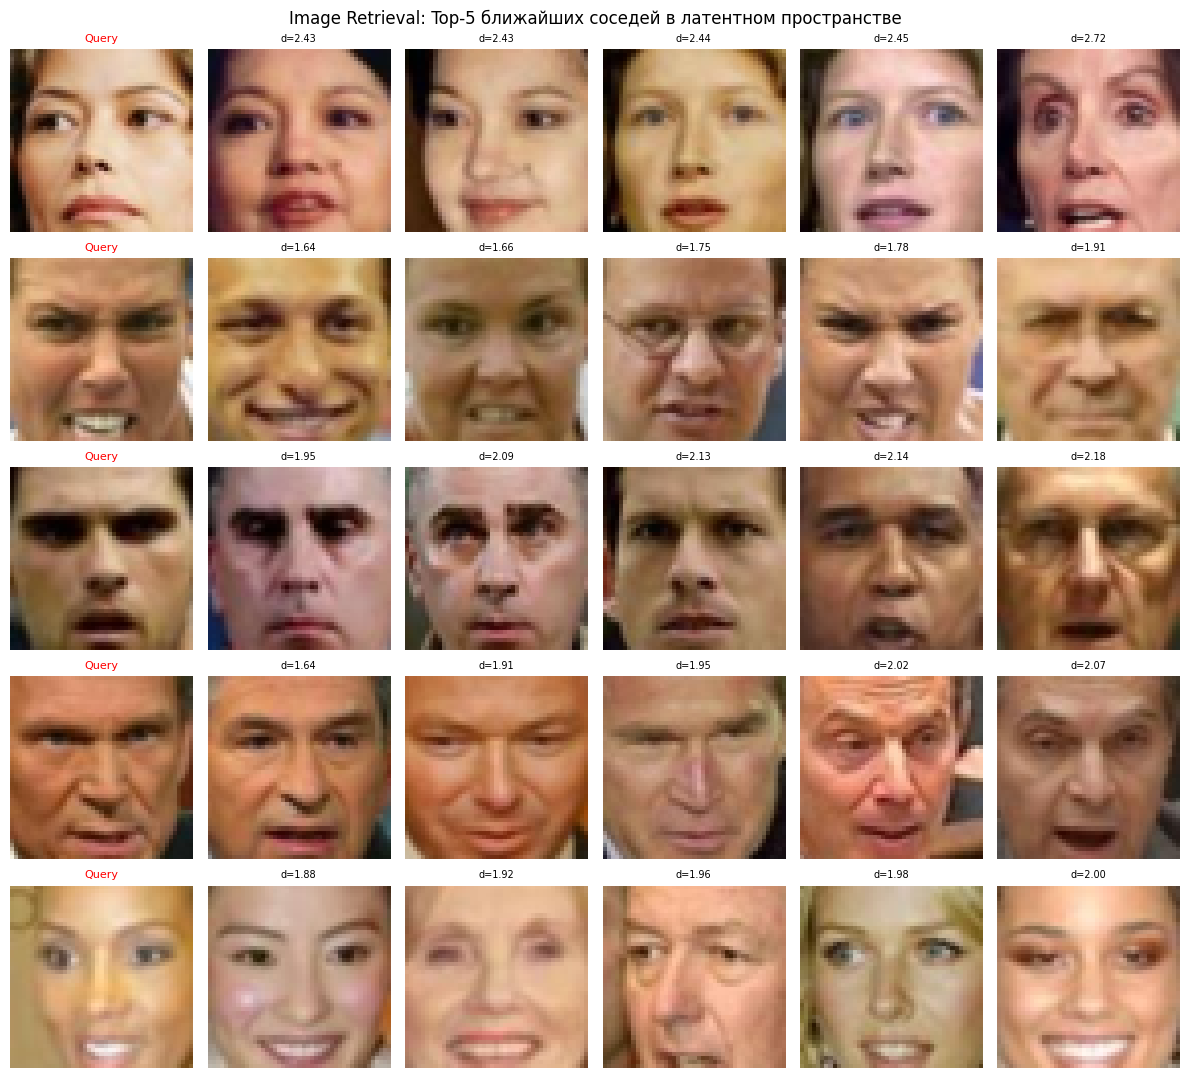

In [ ]:
from sklearn.neighbors import NearestNeighbors

retrieval_loader = data_utils.DataLoader(
    data_utils.TensorDataset(X_train_t),
    batch_size=64, shuffle=False
)

autoencoder.eval()
train_codes = []

with torch.no_grad():
    for (batch,) in retrieval_loader:
        codes = autoencoder.encoder(batch.to(device))
        train_codes.append(codes.cpu().numpy())

train_codes = np.concatenate(train_codes, axis=0)
print(f"Train codes shape: {train_codes.shape}")

nn_index = NearestNeighbors(n_neighbors=10, algorithm='ball_tree', metric='euclidean', n_jobs=-1)
nn_index.fit(train_codes)
print("NearestNeighbors index built!")

N_QUERIES = 5
query_imgs = X_val_t[:N_QUERIES]

autoencoder.eval()
with torch.no_grad():
    query_codes = autoencoder.encoder(query_imgs.to(device)).cpu().numpy()

print(f"Query codes shape: {query_codes.shape}")

K = 5
distances, indices = nn_index.kneighbors(query_codes, n_neighbors=K)
print(f"Найдены ближайшие соседи, distances shape: {distances.shape}")

fig, axes = plt.subplots(N_QUERIES, K + 1, figsize=((K + 1) * 2, N_QUERIES * 2.2))

for row in range(N_QUERIES):
    axes[row, 0].imshow(query_imgs[row].permute(1, 2, 0).clamp(0, 1))
    axes[row, 0].set_title("Query", fontsize=8, color='red')
    axes[row, 0].axis('off')
    for spine in axes[row, 0].spines.values():
        spine.set_edgecolor('red'); spine.set_linewidth(2); spine.set_visible(True)

    for col, (idx, dist) in enumerate(zip(indices[row], distances[row])):
        neighbor_img = X_train_t[idx].permute(1, 2, 0).clamp(0, 1)
        axes[row, col + 1].imshow(neighbor_img)
        axes[row, col + 1].set_title(f"d={dist:.2f}", fontsize=7)
        axes[row, col + 1].axis('off')

for row in range(N_QUERIES):
    axes[row, 0].set_ylabel(f"Query {row+1}", fontsize=8)

plt.suptitle(f"Image Retrieval: Top-{K} ближайших соседей в латентном пространстве", fontsize=12)
plt.tight_layout()
plt.savefig("output/image_retrieval.png", dpi=150)
plt.show()

In [ ]:
from sklearn.neighbors import NearestNeighbors

nn_index = NearestNeighbors(n_neighbors=5, algorithm='ball_tree', metric='euclidean', n_jobs=-1)
nn_index.fit(train_codes)
print("Index built!")

Index built!


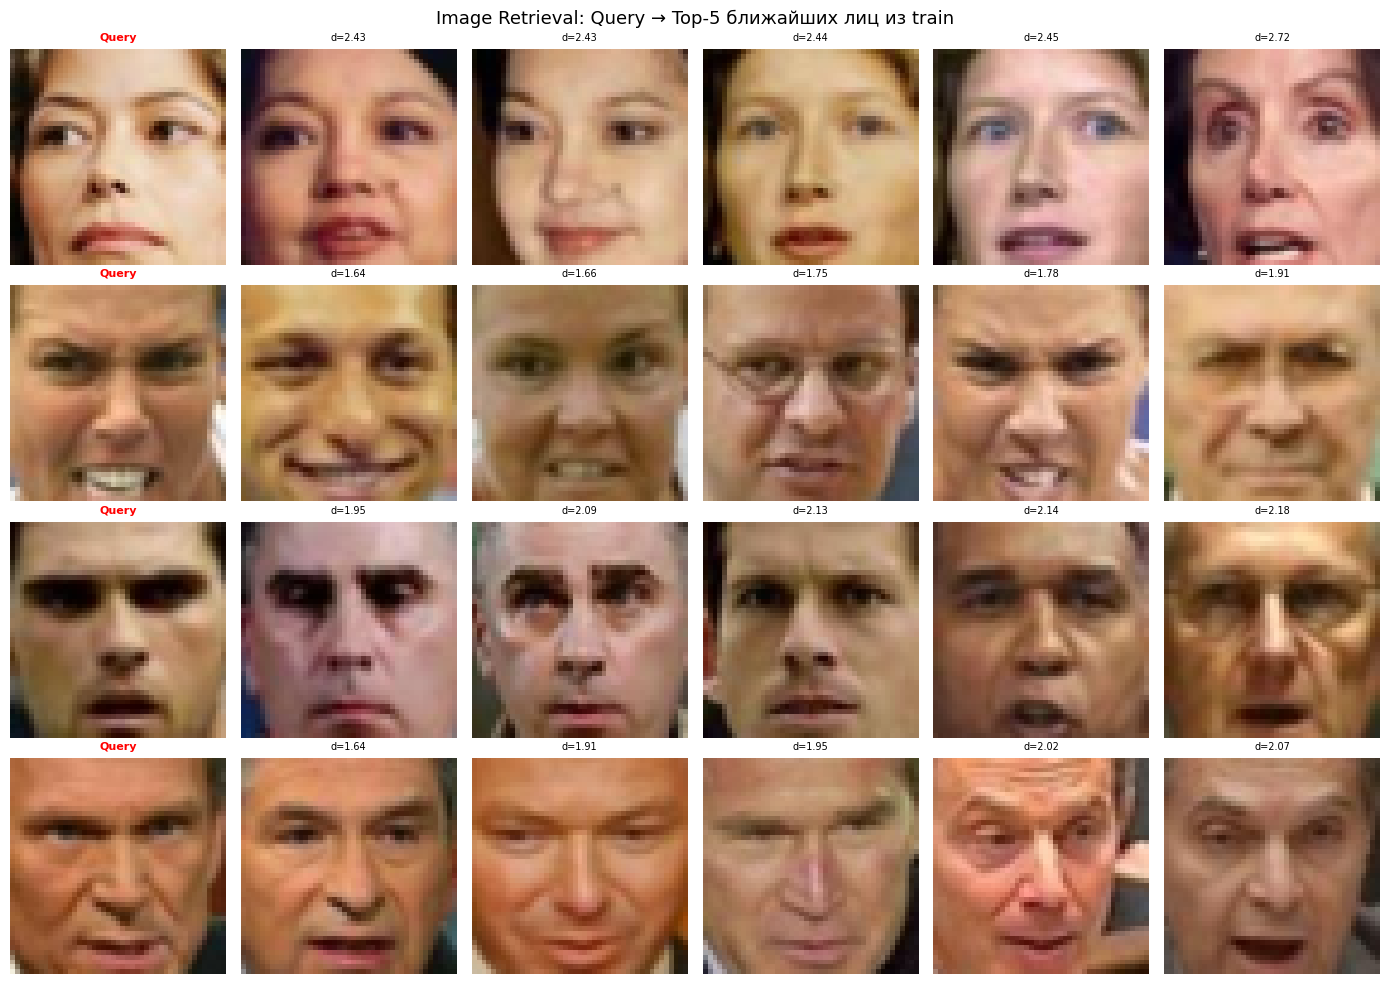

In [ ]:
def get_similar(image, n_neighbors=5):
    """
    image: torch.Tensor (1, C, H, W) или (C, H, W) — тестовое изображение
    Возвращает: distances, похожие картинки из X_train_t
    """
    autoencoder.eval()
    with torch.no_grad():
        img_batch = image.unsqueeze(0).to(device) if image.dim() == 3 else image.to(device)
        code = autoencoder.encoder(img_batch).cpu().numpy()

    distances, indices = nn_index.kneighbors(code, n_neighbors=n_neighbors)
    distances = distances[0]
    idx       = indices[0]

    return distances, X_train_t[idx]

N_QUERIES = 4

fig, axes = plt.subplots(N_QUERIES, 6, figsize=(14, N_QUERIES * 2.5))

for row in range(N_QUERIES):
    query_img = X_val_t[row]
    distances, similar_imgs = get_similar(query_img, n_neighbors=5)

    axes[row, 0].imshow(query_img.permute(1,2,0).clamp(0,1))
    axes[row, 0].set_title("Query", fontsize=8, color='red', fontweight='bold')
    axes[row, 0].axis('off')
    for spine in axes[row, 0].spines.values():
        spine.set_visible(True); spine.set_edgecolor('red'); spine.set_linewidth(2)

    for col in range(5):
        axes[row, col+1].imshow(similar_imgs[col].permute(1,2,0).clamp(0,1))
        axes[row, col+1].set_title(f"d={distances[col]:.2f}", fontsize=7)
        axes[row, col+1].axis('off')

plt.suptitle("Image Retrieval: Query → Top-5 ближайших лиц из train", fontsize=13)
plt.tight_layout()
plt.savefig("output/image_retrieval_final.png", dpi=150)
plt.show()

In [ ]:
def show_similar(image):

  # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances,neighbors = get_similar(image,n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image.cpu().numpy().transpose([1,2,0]))
    plt.title("Original image")

    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1,2,0]))
        plt.title("Dist=%.3f"%distances[i])
    plt.show()


--- Query: val[0] ---


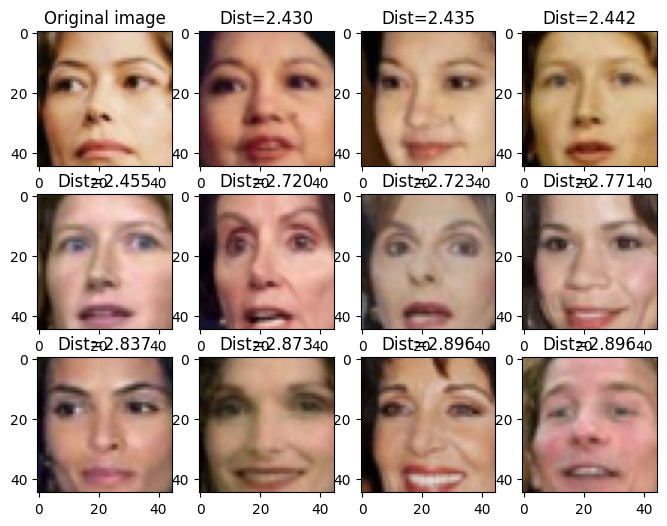


--- Query: val[42] ---


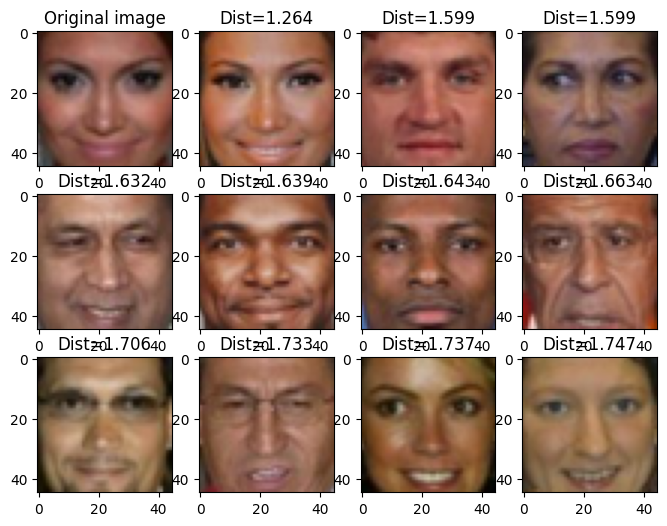


--- Query: val[100] ---


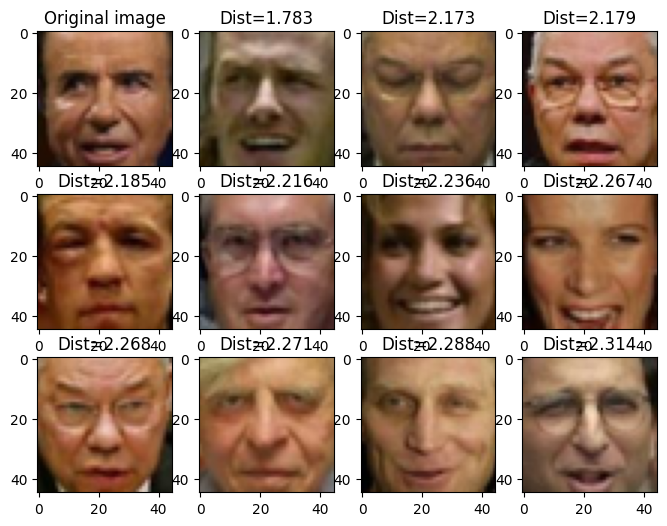


--- Query: val[200] ---


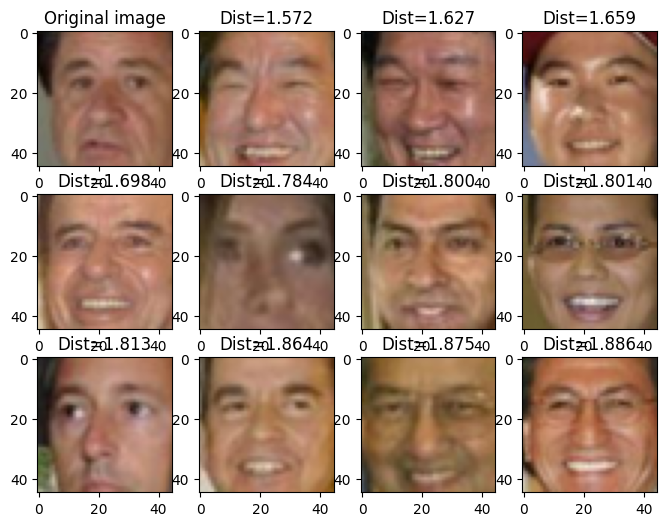

Улыбающийся человек: val[1]


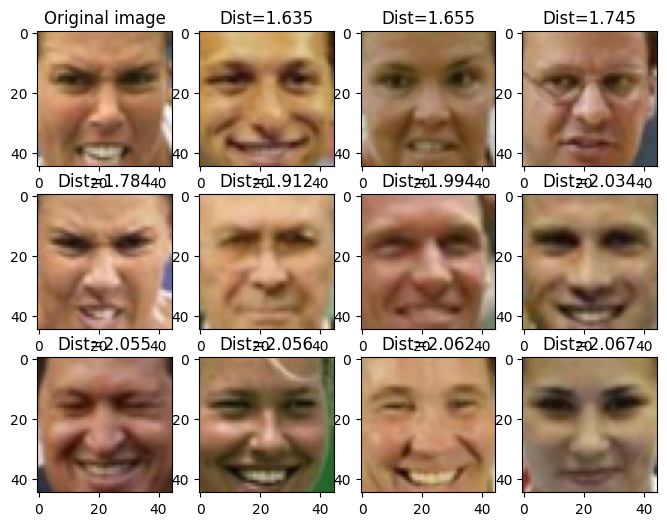

Мужчина: val[1]


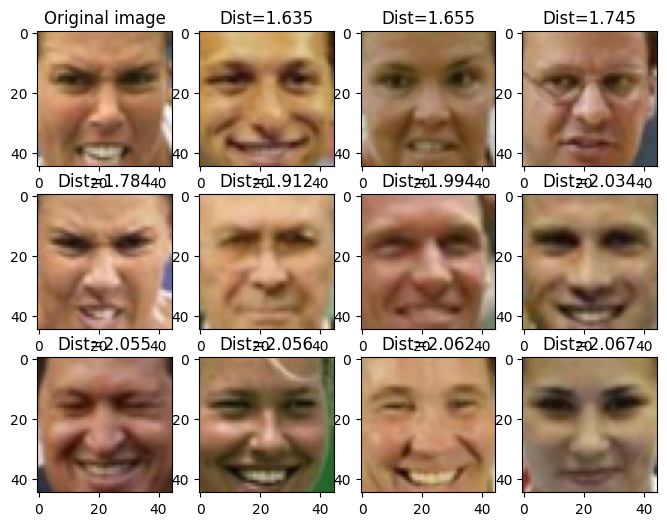

In [ ]:
test_indices = [0, 42, 100, 200]

for idx in test_indices:
    print(f"\n--- Query: val[{idx}] ---")
    show_similar(X_val_t[idx])

smile_val_idx = np.where(attrs_val['Smiling'] > 0)[0][0]
print(f"Улыбающийся человек: val[{smile_val_idx}]")
show_similar(X_val_t[smile_val_idx])

male_val_idx = np.where(attrs_val['Male'] > 0)[0][0]
print(f"Мужчина: val[{male_val_idx}]")
show_similar(X_val_t[male_val_idx])